## 07 Xenium Pooled Pseudotime

**What this notebook does:** Pools niche feature tables from all Xenium samples, fits a unified ElPiGraph principal tree, infers pseudotime and branch labels across samples, and maps results back to cells.

**Data files needed:**
- `data/xenium_pancreas_10x/niche_features/` (from notebook 07_xenium_02)
- `data/xenium_pancreas_10x/annotated_h5ad/` (from notebook 07_xenium_01)

**How to run:** Run notebooks 07_xenium_00 through 07_xenium_02 first.

In [1]:
from pathlib import Path
# DATA AVAILABILITY CHECK
import os
# Pooled pseudotime requires niche feature data
_output_dir = Path("/Users/shihongwu/SpatioEv") / "data" / "xenium_pancreas_10x"
_niche_dir = _output_dir / "niche_features"
_required_files = [_output_dir, _niche_dir]
_missing = [f for f in _required_files if not os.path.exists(f)]
if _missing:
    print(f'Missing required data files: {_missing}')
    print('   This notebook requires real experimental data to run.')
    print('   The code is shown for reference.')
else:
    print('All required data files found. Notebook is ready to run.')


All required data files found. Notebook is ready to run.


# Pooled Xenium Pancreas/PDAC Niche Pseudotime

This notebook fits a pooled epithelial-niche trajectory across three 10x Xenium PDAC datasets and one nondiseased pancreas dataset.

Interpretation guardrail:

This is a cross-sample **morphologic/transcriptomic spatial continuum**, not literal patient time. The value is that SpatioEv can align normal-like, PanIN-like, proliferative, desmoplastic, and immune-remodeled epithelial niches onto a shared tree.


In [2]:

%matplotlib inline

import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba")

from pathlib import Path
import gc
import json
import importlib.util
import tarfile
import warnings
from io import StringIO

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 8
sns.set_style("white")

ROOT = Path("/Users/shihongwu/SpatioEv")
DATA_ROOT = Path("/Volumes/Shihong_5/for_spatioev/pancreas_Xenium_example_data_from_10X")
OUTPUT_DIR = ROOT / "data" / "xenium_pancreas_10x"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_CONFIGS = [
    {
        "sample_id": "pdac_pancreas_v1",
        "display_name": "Human Pancreas FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Multi-Tissue and Cancer",
        "outs_path": DATA_ROOT / "Xenium_V1_human_Pancreas_FFPE_outs",
    },
    {
        "sample_id": "pdac_io_v1",
        "display_name": "Human Ductal Adenocarcinoma FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Immuno-Oncology",
        "outs_path": DATA_ROOT / "Xenium_V1_Human_Ductal_Adenocarcinoma_FFPE_outs",
    },
    {
        "sample_id": "pdac_addon_v1",
        "display_name": "hPancreas Cancer Add-on FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Multi-Tissue + Add-on",
        "outs_path": DATA_ROOT / "Xenium_V1_hPancreas_Cancer_Add_on_FFPE_outs",
    },
    {
        "sample_id": "normal_nondiseased_v1",
        "display_name": "hPancreas nondiseased section",
        "disease_group": "NormalPancreas",
        "panel_hint": "Human Multi-Tissue and Cancer",
        "outs_path": DATA_ROOT / "Xenium_V1_hPancreas_nondiseased_section_outs",
    },
]

CLINICAL_SAMPLE_METADATA = {
    "normal_nondiseased_v1": {
        "clinical_diagnosis": "Nondiseased pancreas",
        "clinical_stage": "Normal",
        "clinical_grade": "Normal",
        "clinical_grade_order": 0.0,
        "tumor_content_percent": 0.0,
        "clinical_progression_label": "Normal pancreas",
        "clinical_progression_order": 0,
        "clinical_note": "10x nondiseased pancreas reference",
    },
    "pdac_addon_v1": {
        "clinical_diagnosis": "Adenocarcinoma",
        "clinical_stage": "Not provided",
        "clinical_grade": "Grade I-II",
        "clinical_grade_order": 1.5,
        "tumor_content_percent": 50.0,
        "clinical_progression_label": "Grade I-II, 50% tumor",
        "clinical_progression_order": 1,
        "clinical_note": "10x pancreas cancer add-on sample; adenocarcinoma, Grade I-II, 50% tumor",
    },
    "pdac_pancreas_v1": {
        "clinical_diagnosis": "Adenocarcinoma",
        "clinical_stage": "Stage III",
        "clinical_grade": "Not provided",
        "clinical_grade_order": np.nan,
        "tumor_content_percent": np.nan,
        "clinical_progression_label": "Stage III adenocarcinoma",
        "clinical_progression_order": 2,
        "clinical_note": "10x human pancreas FFPE sample; Stage III adenocarcinoma",
    },
    "pdac_io_v1": {
        "clinical_diagnosis": "Pancreatic ductal adenocarcinoma",
        "clinical_stage": "Stage IIB",
        "clinical_grade": "Grade 3",
        "clinical_grade_order": 3.0,
        "tumor_content_percent": np.nan,
        "clinical_progression_label": "Stage IIB, Grade 3 PDAC",
        "clinical_progression_order": 3,
        "clinical_note": "10x human ductal adenocarcinoma FFPE sample; Stage IIB, Grade 3",
    },
}

CLINICAL_SAMPLE_ORDER = [
    "normal_nondiseased_v1",
    "pdac_addon_v1",
    "pdac_pancreas_v1",
    "pdac_io_v1",
]
CLINICAL_LABEL_ORDER = [
    CLINICAL_SAMPLE_METADATA[sample_id]["clinical_progression_label"]
    for sample_id in CLINICAL_SAMPLE_ORDER
]
CLINICAL_PALETTE = {
    "Normal pancreas": "#4daf4a",
    "Grade I-II, 50% tumor": "#ffb000",
    "Stage III adenocarcinoma": "#e41a1c",
    "Stage IIB, Grade 3 PDAC": "#6a3d9a",
}

def clinical_metadata_frame():
    return (
        pd.DataFrame.from_dict(CLINICAL_SAMPLE_METADATA, orient="index")
        .rename_axis("sample_id")
        .reset_index()
        .sort_values("clinical_progression_order")
    )

def attach_clinical_metadata(df):
    meta = clinical_metadata_frame()
    existing_meta_cols = [col for col in meta.columns if col != "sample_id" and col in df.columns]
    if existing_meta_cols:
        df = df.drop(columns=existing_meta_cols)
    return df.merge(meta, on="sample_id", how="left", validate="many_to_one")

def package_available(name):
    return importlib.util.find_spec(name) is not None

def save_df(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix == ".pkl":
        df.to_pickle(path)
    else:
        df.to_csv(path, index=index)

def load_df(path):
    path = Path(path)
    if path.suffix == ".pkl":
        return pd.read_pickle(path)
    return pd.read_csv(path)

def present_columns(df, cols):
    return [c for c in cols if c in df.columns]

def make_sparse_safe_copy(X):
    return X.copy() if sparse.issparse(X) else np.asarray(X).copy()


In [3]:

import elpigraph
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from spatioev.tl.pseudotime import (
    zscore_series as sv_zscore_series,
    prepare_pseudotime_feature_matrix,
    assign_feature_blocks,
    block_balance_feature_matrix as sv_block_balance_feature_matrix,
)

# ── Nature/Cell publication rcParams ─────────────────────────────────────────
import matplotlib as mpl
_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial","Helvetica","DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5, "lines.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "white", "figure.facecolor": "white",
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
}
mpl.rcParams.update(_pub_rc)
DISEASE_PALETTE = {"NormalPancreas": "#4CAF50", "PDAC": "#D32F2F"}
SAMPLE_PALETTE = {
    "normal_nondiseased_v1": "#4CAF50",
    "pdac_addon_v1":         "#7B1FA2",
    "pdac_pancreas_v1":      "#E65100",
    "pdac_io_v1":            "#1565C0",
}

NICHE_KEY = "xenium_ductal_epithelium_component"
NICHE_DIR = OUTPUT_DIR / "niche_features"
RESULT_DIR = OUTPUT_DIR / "pseudotime"
RESULT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
SIMPLIFIED_NUM_NODES = 15   # [reason] 5074 niches → ~15 nodes adequate; 24 was overfit
DETAILED_TREE_MIN_NODES = 40
DETAILED_TREE_MAX_NODES = 50    # [reason] ~50 niches/node vs ~100 in original — reduces overfitting
DETAILED_TREE_NODE_SCALE = 2.5
EXPECTED_NICHE_FEATURE_VERSION = "boundary_components_v3_lumen_continuity_interface"
EXPECTED_DAPI_FEATURE_VERSION = "user_verified_focus_dapi_sources_v2"
EXPECTED_ANNOTATION_VERSION = "cluster_full_panel_v9_xenium_graphclust_io_mucosa_submucosa_k24"

pooled_niche_feature_df = attach_clinical_metadata(load_df(OUTPUT_DIR / "pooled_xenium_niche_feature_df.pkl"))
print(pooled_niche_feature_df.shape)
clinical_sample_metadata_df = clinical_metadata_frame()
display(
    clinical_sample_metadata_df[
        [
            "sample_id",
            "clinical_diagnosis",
            "clinical_stage",
            "clinical_grade",
            "tumor_content_percent",
            "clinical_progression_label",
        ]
    ]
)

version_cols = [
    col for col in [
        "sample_id",
        "xenium_annotation_version",
        "xenium_niche_feature_version",
        "xenium_dapi_feature_version",
    ]
    if col in pooled_niche_feature_df.columns
]
if len(version_cols) > 1:
    version_summary_df = pooled_niche_feature_df[version_cols].drop_duplicates().sort_values("sample_id")
    display(version_summary_df)
else:
    print("No upstream version metadata found. Rerun notebook 02 with the current workflow before final interpretation.")

if "xenium_annotation_version" in pooled_niche_feature_df.columns:
    annotation_versions = set(pooled_niche_feature_df["xenium_annotation_version"].dropna().astype(str))
    if annotation_versions != {EXPECTED_ANNOTATION_VERSION}:
        print(f"Warning: annotation versions differ from expected {EXPECTED_ANNOTATION_VERSION}: {sorted(annotation_versions)}")
else:
    print("Warning: xenium_annotation_version is missing; rerun notebook 02 after notebook 01.")

if "xenium_niche_feature_version" in pooled_niche_feature_df.columns:
    niche_versions = set(pooled_niche_feature_df["xenium_niche_feature_version"].dropna().astype(str))
    if niche_versions != {EXPECTED_NICHE_FEATURE_VERSION}:
        print(f"Warning: niche feature versions differ from expected {EXPECTED_NICHE_FEATURE_VERSION}: {sorted(niche_versions)}")

if "xenium_dapi_feature_version" in pooled_niche_feature_df.columns:
    dapi_versions = set(pooled_niche_feature_df["xenium_dapi_feature_version"].fillna("none").astype(str))
    if dapi_versions == {"none"}:
        print("DAPI full epithelial features are not included yet. This is OK for a first run; run full DAPI extraction in notebook 02 to include nuclear texture.")
    elif dapi_versions != {EXPECTED_DAPI_FEATURE_VERSION}:
        print(f"Warning: DAPI feature versions differ from expected {EXPECTED_DAPI_FEATURE_VERSION}: {sorted(dapi_versions)}")

pooled_niche_feature_df.head()


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(5074, 2159)


,sample_id,clinical_diagnosis,clinical_stage,clinical_grade,tumor_content_percent,clinical_progression_label
0,normal_nondiseased_v1,Nondiseased pancreas,Normal,Normal,0.0,Normal pancreas
1,pdac_addon_v1,Adenocarcinoma,Not provided,Grade I-II,50.0,"Grade I-II, 50% tumor"
2,pdac_pancreas_v1,Adenocarcinoma,Stage III,Not provided,NaN,Stage III adenocarcinoma
3,pdac_io_v1,Pancreatic ductal adenocarcinoma,Stage IIB,Grade 3,NaN,"Stage IIB, Grade 3 PDAC"


,sample_id,xenium_annotation_version,xenium_niche_feature_version,xenium_dapi_feature_version
3297,normal_nondiseased_v1,cluster_full_panel_v9_xenium_graphclust_io_muc...,boundary_components_v3_lumen_continuity_interface,user_verified_focus_dapi_sources_v2
2082,pdac_addon_v1,cluster_full_panel_v9_xenium_graphclust_io_muc...,boundary_components_v3_lumen_continuity_interface,user_verified_focus_dapi_sources_v2
1495,pdac_io_v1,cluster_full_panel_v9_xenium_graphclust_io_muc...,boundary_components_v3_lumen_continuity_interface,user_verified_focus_dapi_sources_v2
0,pdac_pancreas_v1,cluster_full_panel_v9_xenium_graphclust_io_muc...,boundary_components_v3_lumen_continuity_interface,user_verified_focus_dapi_sources_v2


,xenium_ductal_epithelium_component,image_id,n_cells,topology__n_nodes,topology__n_edges,topology__density,topology__avg_degree,topology__degree_var,topology__degree_cv,topology__leaf_fraction,...,surround__Myeloid_cells__ITGAX_expr_z__mean,surround__Myeloid_cells__ITGAX_expr_z__median,clinical_diagnosis,clinical_stage,clinical_grade,clinical_grade_order,tumor_content_percent,clinical_progression_label,clinical_progression_order,clinical_note
0,pdac_pancreas_v1__ductal_boundary_00001,pdac_pancreas_v1,6.0,6.0,15.0,1.000000,5.000000,0.000000,0.000000,0.0,...,NaN,NaN,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,2,10x human pancreas FFPE sample; Stage III aden...
1,pdac_pancreas_v1__ductal_boundary_00002,pdac_pancreas_v1,155.0,155.0,1402.0,0.117470,18.090323,34.688616,0.325572,0.0,...,NaN,NaN,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,2,10x human pancreas FFPE sample; Stage III aden...
2,pdac_pancreas_v1__ductal_boundary_00003,pdac_pancreas_v1,13.0,13.0,42.0,0.538462,6.461538,1.940828,0.215604,0.0,...,NaN,NaN,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,2,10x human pancreas FFPE sample; Stage III aden...
3,pdac_pancreas_v1__ductal_boundary_00004,pdac_pancreas_v1,10.0,10.0,38.0,0.844444,7.600000,1.640000,0.168503,0.0,...,NaN,NaN,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,2,10x human pancreas FFPE sample; Stage III aden...
4,pdac_pancreas_v1__ductal_boundary_00005,pdac_pancreas_v1,11.0,11.0,40.0,0.727273,7.272727,3.107438,0.242384,0.0,...,NaN,NaN,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,2,10x human pancreas FFPE sample; Stage III aden...


In [4]:

MODULE_COLS = [
    "xenium_epithelial_identity_score",
    "xenium_panin_like_remodeling_score",
    "xenium_proliferation_score",
    "xenium_desmoplastic_context_score",
    "xenium_immune_context_score",
    "xenium_checkpoint_context_score",
    "xenium_nuclear_dapi_texture_score",
    "xenium_duct_lumen_topology_score",
    "xenium_duct_continuity_cancerization_score",
    "xenium_epithelial_stromal_interface_disruption_score",
]

HISTOLOGY_PROXY_DEFINITIONS = {
    "histology__normal_duct_like_score": [
        ("xenium_epithelial_identity_score", 1),
        ("state__CFTR_expr_z__mean", 1),
        ("state__FXYD2_expr_z__mean", 1),
        ("state__TM4SF4_expr_z__mean", 1),
        ("state__PROX1_expr_z__mean", 1),
        ("xenium_panin_like_remodeling_score", -1),
        ("xenium_proliferation_score", -1),
        ("xenium_desmoplastic_context_score", -1),
    ],
    "histology__adm_panin_like_score": [
        ("xenium_panin_like_remodeling_score", 1),
        ("state__MUC5AC_expr_z__mean", 1),
        ("state__TFF1_expr_z__mean", 1),
        ("state__TFF2_expr_z__mean", 1),
        ("state__TFF3_expr_z__mean", 1),
        ("state__CEACAM6_expr_z__mean", 1),
        ("state__AGR3_expr_z__mean", 1),
        ("state__SOX9_expr_z__mean", 1),
    ],
    "histology__glandular_architecture_score": [
        ("xenium_epithelial_identity_score", 1),
        ("xenium_duct_lumen_topology_score", 1),
        ("geometry__hull_circularity", 1),
        ("geometry__orientation_coherence", 1),
        ("duct_lumen__lumen_fraction", 1),
        ("duct_lumen__epithelial_ring_thickness_um", 1),
        ("topology__skeleton_branchpoint_fraction", 1),
        ("topology__skeleton_n_edges", 1),
        ("topology__skeleton_total_length", 1),
        ("geometry__cell_density_hull", -1),
    ],
    "histology__ductal_continuity_cancerization_score": [
        ("xenium_duct_continuity_cancerization_score", 1),
        ("duct_continuity__component_axis_length_um", 1),
        ("duct_continuity__component_axis_ratio", 1),
        ("duct_continuity__nearby_components_150um", 1),
        ("duct_continuity__neighbor_orientation_alignment_150um", 1),
        ("duct_continuity__nearest_component_distance_um", -1),
    ],
    "histology__epithelial_stromal_interface_disruption_score": [
        ("xenium_epithelial_stromal_interface_disruption_score", 1),
        ("interface__epithelial_boundary_roughness", 1),
        ("interface__nearby_unassigned_epithelial_cells_per_100um_boundary", 1),
        ("interface__fibroblast_contact_fraction_hop1", 1),
        ("interface__non_epithelial_contact_fraction_hop1", 1),
    ],
    "histology__desmoplastic_tumor_score": [
        ("xenium_desmoplastic_context_score", 1),
        ("xenium_epithelial_stromal_interface_disruption_score", 1),
        ("surround_prop__Fibroblasts", 1),
        ("surround__Fibroblasts__ACTA2_expr_z__mean", 1),
        ("surround__Fibroblasts__PDGFRA_expr_z__mean", 1),
        ("surround__Fibroblasts__THY1_expr_z__mean", 1),
        ("surround__Fibroblasts__PDPN_expr_z__mean", 1),
        ("graph_surround__phenotype_entropy", 1),
    ],
    "histology__immune_inflamed_score": [
        ("xenium_immune_context_score", 1),
        ("xenium_checkpoint_context_score", 1),
        ("surround_prop__T_cells", 1),
        ("surround_prop__B_lineage", 1),
        ("surround_prop__Myeloid_cells", 1),
        ("surround__T_cells__CD3D_expr_z__mean", 1),
        ("surround__B_lineage__CD79A_expr_z__mean", 1),
    ],
    "histology__immune_exclusion_score": [
        ("xenium_immune_context_score", -1),
        ("surround_prop__T_cells", -1),
        ("surround_prop__B_lineage", -1),
        ("surround_prop__Myeloid_cells", -1),
        ("graph_surround__phenotype_entropy", -1),
    ],
    "histology__duodenum_invasion_context_score": [
        ("surround_prop__Mucosa_gland", 1),
        ("surround_prop__Submucosa", 1),
        ("surround__Duodenum_epithelial__DMBT1_expr_z__mean", 1),
        ("surround__Duodenum_epithelial__KRT20_expr_z__mean", 1),
    ],
    "histology__gland_poor_undifferentiated_score": [
        ("histology__glandular_architecture_score", -1),
        ("histology__epithelial_stromal_interface_disruption_score", 1),
        ("xenium_epithelial_identity_score", -1),
        ("xenium_proliferation_score", 1),
        ("histology__immune_exclusion_score", 1),
        ("xenium_desmoplastic_context_score", -1),
    ],
}

def _zscore_series(values):
    values = pd.to_numeric(values, errors="coerce")
    sd = values.std(ddof=0)
    if not np.isfinite(sd) or np.isclose(sd, 0):
        return pd.Series(np.nan, index=values.index)
    return (values - values.mean()) / sd

def add_histology_proxy_scores(df, definitions):
    df = df.copy()
    availability_rows = []
    for score_name, components in definitions.items():
        component_values = []
        used = []
        missing = []
        for col, sign in components:
            if col not in df.columns:
                missing.append(col)
                continue
            component_values.append(sign * _zscore_series(df[col]))
            used.append(col)
        if len(component_values) == 0:
            df[score_name] = np.nan
        else:
            df[score_name] = pd.concat(component_values, axis=1).mean(axis=1, skipna=True)
        availability_rows.append(
            {
                "score": score_name,
                "n_used": len(used),
                "n_missing": len(missing),
                "used_features": ", ".join(used),
                "missing_features": ", ".join(missing),
            }
        )
    return df, pd.DataFrame(availability_rows)

pooled_niche_feature_df, histology_proxy_availability_df = add_histology_proxy_scores(
    pooled_niche_feature_df,
    HISTOLOGY_PROXY_DEFINITIONS,
)
HISTOLOGY_PROXY_COLS = [col for col in HISTOLOGY_PROXY_DEFINITIONS if col in pooled_niche_feature_df.columns]
MODULE_COLS = list(dict.fromkeys(MODULE_COLS + HISTOLOGY_PROXY_COLS))

display(histology_proxy_availability_df)

SUPPLEMENTAL_PATTERNS = [
    "duct_lumen__",
    "duct_continuity__",
    "interface__",
    "geometry__",
    "topology__skeleton",
    "surround_prop__",
    "state__EPCAM",
    "state__KRT7",
    "state__SOX9",
    "state__MUC5AC",
    "state__TFF",
    "state__CEACAM6",
    "state__AGR3",
    "state__MKI67",
    "state__UBE2C",
    "state__TOP2A",
    "state__dapi_",
    "state__nucleus_boundary",
]

def prepare_feature_matrix(df, feature_cols, max_na_frac=0.45, corr_cutoff=0.97):
    X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    X = X.loc[:, X.isna().mean() <= max_na_frac]
    X = X.apply(lambda col: col.fillna(col.median()), axis=0)
    X = X.loc[:, X.var(ddof=0) > 1e-8]

    priority = [c for c in MODULE_COLS if c in X.columns]
    candidates = [c for c in X.columns if c not in priority]
    corr_abs = X.corr().abs()
    selected = list(priority)
    for col in candidates:
        if not selected:
            selected.append(col)
            continue
        max_corr = corr_abs.loc[col, selected].dropna().max()
        if not np.isfinite(max_corr) or max_corr < corr_cutoff:
            selected.append(col)
    return X[selected].copy(), selected

candidate_cols = []
for col in pooled_niche_feature_df.columns:
    if col in MODULE_COLS:
        candidate_cols.append(col)
    elif any(col.startswith(pattern) for pattern in SUPPLEMENTAL_PATTERNS):
        candidate_cols.append(col)

X_pool, selected_cols = prepare_feature_matrix(pooled_niche_feature_df, candidate_cols)
print(f"Selected {len(selected_cols)} trajectory features")
pd.Series(selected_cols, name="feature").to_frame().head(25)


,score,n_used,n_missing,used_features,missing_features
0,histology__normal_duct_like_score,8,0,"xenium_epithelial_identity_score, state__CFTR_...",
1,histology__adm_panin_like_score,7,1,"xenium_panin_like_remodeling_score, state__MUC...",state__TFF1_expr_z__mean
2,histology__glandular_architecture_score,10,0,"xenium_epithelial_identity_score, xenium_duct_...",
3,histology__ductal_continuity_cancerization_score,6,0,"xenium_duct_continuity_cancerization_score, du...",
4,histology__epithelial_stromal_interface_disrup...,5,0,xenium_epithelial_stromal_interface_disruption...,
5,histology__desmoplastic_tumor_score,8,0,"xenium_desmoplastic_context_score, xenium_epit...",
6,histology__immune_inflamed_score,7,0,"xenium_immune_context_score, xenium_checkpoint...",
7,histology__immune_exclusion_score,5,0,"xenium_immune_context_score, surround_prop__T_...",
8,histology__duodenum_invasion_context_score,4,0,"surround_prop__Mucosa_gland, surround_prop__Su...",
9,histology__gland_poor_undifferentiated_score,6,0,"histology__glandular_architecture_score, histo...",


Selected 293 trajectory features


,feature
0,xenium_epithelial_identity_score
1,xenium_panin_like_remodeling_score
2,xenium_proliferation_score
3,xenium_desmoplastic_context_score
4,xenium_immune_context_score
5,xenium_checkpoint_context_score
6,xenium_nuclear_dapi_texture_score
7,xenium_duct_lumen_topology_score
8,xenium_duct_continuity_cancerization_score
9,xenium_epithelial_stromal_interface_disruption...


,feature_block,n_features
0,nuclear_morphology,177
1,epithelial_state,42
2,architecture_topology,26
3,duct_architecture,12
4,other,10
5,histology_modules,9
6,epithelial_stromal_interface,9
7,microenvironment,8


PCA fit subset: 5074 niches (1777 normal + 3297 PDAC)


/Users/shihongwu/SpatioEv/spatioev/tl/pseudotime.py:296: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.03730923 -0.40832894 -0.28253289 ...  0.3464474   0.09485528
 -0.40832894]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, :] = StandardScaler().fit_transform(X)
/Users/shihongwu/SpatioEv/spatioev/tl/pseudotime.py:296: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-2.16393379 -1.85629881 -2.0101163  ...  0.29714605  0.45096354
  0.60478103]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, :] = StandardScaler().fit_transform(X)
/Users/shihongwu/SpatioEv/spatioev/tl/pseudotime.py:296: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.54526604 -0.21335618 -0.45474517 ... 

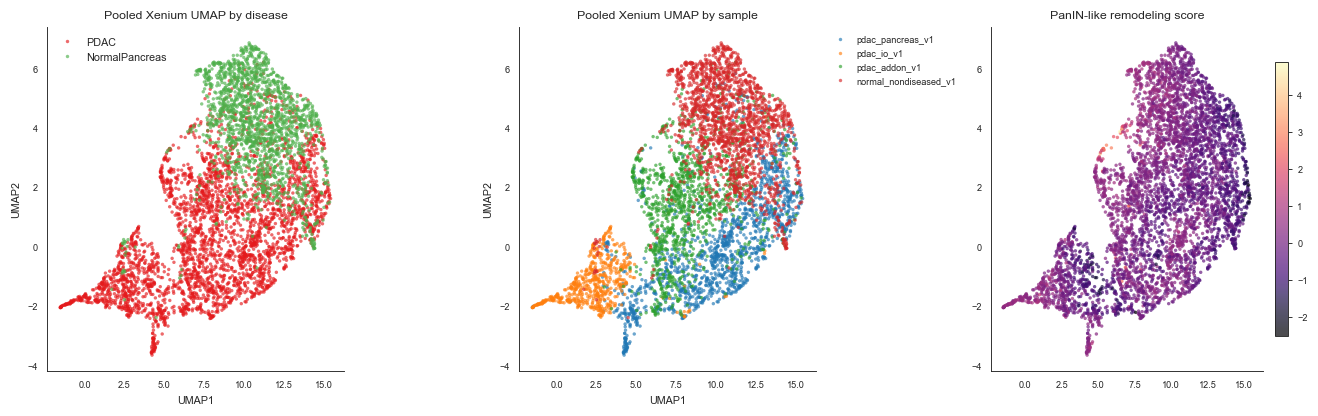

In [5]:

TRAJECTORY_SCALING = "block_balanced"

# ── Feature scaling: block-balanced + balanced-subsampling PCA ───────────────
# [reason] sv.tl.assign_feature_blocks uses DEFAULT_FEATURE_BLOCK_RULES;
# sv.tl.block_balance_feature_matrix equalises broad feature families.
# Balanced subsampling (≤3:1 PDAC:normal) prevents the 4:1 PDAC:normal ratio
# from dominating the PCA scaler — matching the IMC combined notebook approach.

feature_block_df = assign_feature_blocks(X_pool.columns.tolist())
display(feature_block_df["feature_block"].value_counts().rename("n_features").reset_index())

# Block-balance and z-score
X_scaled_df = sv_block_balance_feature_matrix(X_pool, feature_blocks=feature_block_df)
X_scaled = X_scaled_df.to_numpy()

# ── Disease-group balanced subsampling for PCA fitting ───────────────────────
# [reason] 3 PDAC samples : 1 normal → normal niches at risk of marginalisation.
# Fit the PCA scaler on a balanced subsample (≤3:1 PDAC:normal), then project ALL.
_disease_col   = "disease_group"
_normal_label  = "NormalPancreas"
_n_normal      = int((pooled_niche_feature_df[_disease_col] == _normal_label).sum())
_pdac_idx      = pooled_niche_feature_df.index[pooled_niche_feature_df[_disease_col] != _normal_label].tolist()
_normal_idx    = pooled_niche_feature_df.index[pooled_niche_feature_df[_disease_col] == _normal_label].tolist()
_rng_bal       = np.random.default_rng(RANDOM_STATE)
_n_pdac_sub    = min(len(_pdac_idx), _n_normal * 3)
_pdac_idx_sub  = _rng_bal.choice(_pdac_idx, size=_n_pdac_sub, replace=False).tolist()
_fit_idx       = _normal_idx + _pdac_idx_sub
print(f"PCA fit subset: {len(_fit_idx)} niches ({len(_normal_idx)} normal + {len(_pdac_idx_sub)} PDAC)")

pca = PCA(n_components=min(12, X_scaled.shape[1]), random_state=RANDOM_STATE)
pca.fit(X_scaled_df.loc[_fit_idx].to_numpy())
X_pca = pca.transform(X_scaled)
X_pca_use = X_pca[:, : min(6, X_pca.shape[1])]

umap_model = UMAP(
    n_neighbors=15,
    min_dist=0.20,
    n_components=2,
    random_state=RANDOM_STATE,
)
X_umap = umap_model.fit_transform(X_pca_use)

embedding_meta_cols = [
    col
    for col in [
        NICHE_KEY,
        "sample_id",
        "display_name",
        "disease_group",
        "clinical_diagnosis",
        "clinical_stage",
        "clinical_grade",
        "clinical_grade_order",
        "tumor_content_percent",
        "clinical_progression_label",
        "clinical_progression_order",
        "clinical_note",
    ]
    if col in pooled_niche_feature_df.columns
]
embedding_df = pooled_niche_feature_df[embedding_meta_cols].copy()
embedding_df["UMAP1"] = X_umap[:, 0]
embedding_df["UMAP2"] = X_umap[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
sns.scatterplot(
    data=embedding_df,
    x="UMAP1",
    y="UMAP2",
    hue="disease_group",
    palette={"NormalPancreas": "#4daf4a", "PDAC": "#e41a1c"},
    s=5,
    linewidth=0,
    alpha=0.65,
    ax=axes[0],
)
axes[0].set_title("Pooled Xenium UMAP by disease")
axes[0].grid(False)
axes[0].legend(frameon=False, fontsize=7)

sns.scatterplot(
    data=embedding_df,
    x="UMAP1",
    y="UMAP2",
    hue="sample_id",
    palette="tab10",
    s=5,
    linewidth=0,
    alpha=0.65,
    ax=axes[1],
)
axes[1].set_title("Pooled Xenium UMAP by sample")
axes[1].grid(False)
axes[1].legend(frameon=False, fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

scat = axes[2].scatter(
    embedding_df["UMAP1"],
    embedding_df["UMAP2"],
    c=pooled_niche_feature_df["xenium_panin_like_remodeling_score"],
    s=5,
    linewidth=0,
    alpha=0.7,
    cmap="magma",
)
axes[2].set_title("PanIN-like remodeling score")
axes[2].grid(False)
plt.colorbar(scat, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [6]:

reduced_data = X_pca_use
n_niches = reduced_data.shape[0]
num_nodes = int(
    min(
        DETAILED_TREE_MAX_NODES,
        max(DETAILED_TREE_MIN_NODES, np.ceil(np.sqrt(n_niches) * DETAILED_TREE_NODE_SCALE)),
    )
)
num_nodes = int(min(num_nodes, max(2, n_niches - 1)))
num_nodes_simple = int(min(SIMPLIFIED_NUM_NODES, max(2, n_niches - 1)))

pg_tree = elpigraph.computeElasticPrincipalTree(
    X=reduced_data,
    NumNodes=num_nodes,
    Lambda=0.01,
    Mu=0.01,
    MaxNumberOfIterations=50,
)[0]

pg_tree_simple = elpigraph.computeElasticPrincipalTree(
    X=reduced_data,
    NumNodes=num_nodes_simple,
    Lambda=0.01,
    Mu=0.01,
    MaxNumberOfIterations=50,
)[0]

root_score = pd.to_numeric(pooled_niche_feature_df["xenium_epithelial_identity_score"], errors="coerce")
normal_mask = pooled_niche_feature_df["disease_group"] == "NormalPancreas"
root_mask = normal_mask & (root_score >= root_score[normal_mask].quantile(0.85))
if root_mask.sum() == 0:
    root_mask = normal_mask
root_anchor = reduced_data[root_mask.to_numpy()].mean(axis=0)
source_node = int(np.argmin(np.sum((pg_tree["NodePositions"] - root_anchor) ** 2, axis=1)))
source_node_simple = int(np.argmin(np.sum((pg_tree_simple["NodePositions"] - root_anchor) ** 2, axis=1)))

elpigraph.utils.getPseudotime(
    X=reduced_data,
    PG=pg_tree,
    source=source_node,
    target=None,
)

elpigraph.utils.getPseudotime(
    X=reduced_data,
    PG=pg_tree_simple,
    source=source_node_simple,
    target=None,
)

projection = pg_tree["projection"]
projection_simple = pg_tree_simple["projection"]
result_df = embedding_df.copy()
result_df["xenium_pseudotime"] = pg_tree["pseudotime"]
result_df["xenium_node_id"] = projection["node_id"]
result_df["xenium_edge_id"] = projection["edge_id"]
result_df["xenium_simple_pseudotime"] = pg_tree_simple["pseudotime"]
result_df["xenium_simple_node_id"] = projection_simple["node_id"]
result_df["xenium_simple_edge_id"] = projection_simple["edge_id"]
for col in MODULE_COLS:
    if col in pooled_niche_feature_df.columns:
        result_df[col] = pooled_niche_feature_df[col].values

print("NumNodes (detailed tree):", num_nodes)
print("NumNodes (simplified tree):", num_nodes_simple)
print("Root niches:", int(root_mask.sum()))
print("Detailed root node:", source_node)
print("Simplified root node:", source_node_simple)
result_df.head()


NumNodes (detailed tree): 50
NumNodes (simplified tree): 15
Root niches: 267
Detailed root node: 7
Simplified root node: 3


,xenium_ductal_epithelium_component,sample_id,display_name,disease_group,clinical_diagnosis,clinical_stage,clinical_grade,clinical_grade_order,tumor_content_percent,clinical_progression_label,...,histology__normal_duct_like_score,histology__adm_panin_like_score,histology__glandular_architecture_score,histology__ductal_continuity_cancerization_score,histology__epithelial_stromal_interface_disruption_score,histology__desmoplastic_tumor_score,histology__immune_inflamed_score,histology__immune_exclusion_score,histology__duodenum_invasion_context_score,histology__gland_poor_undifferentiated_score
0,pdac_pancreas_v1__ductal_boundary_00001,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,-1.165860,-0.332335,-0.198134,-0.949959,-1.209731,0.467496,-0.382488,0.612701,NaN,-0.410238
1,pdac_pancreas_v1__ductal_boundary_00002,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,-1.223233,0.105292,0.847168,0.873140,1.247642,0.885211,0.609961,-0.679170,NaN,-0.447364
2,pdac_pancreas_v1__ductal_boundary_00003,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,-0.650755,-0.300413,0.547034,-0.654536,1.371208,0.567543,-0.266110,0.562351,NaN,-0.353060
3,pdac_pancreas_v1__ductal_boundary_00004,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,-1.475206,-0.228279,0.321868,0.238404,0.407724,0.308733,-0.240614,0.737182,NaN,0.545060
4,pdac_pancreas_v1__ductal_boundary_00005,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,-1.234137,-0.153540,0.196622,0.640087,-0.958735,1.271319,0.976967,-1.608549,NaN,-1.549467


In [7]:

def tree_edges(pg_tree):
    edges = np.asarray(pg_tree["Edges"][0], dtype=int)
    return [tuple(map(int, edge)) for edge in edges]

def node_graph(pg_tree):
    G = nx.Graph()
    G.add_edges_from(tree_edges(pg_tree))
    return G

def infer_branch_labels(pg_tree, result_df, source_node, node_col="xenium_node_id"):
    G = node_graph(pg_tree)
    degrees = dict(G.degree())
    branch_nodes = [n for n, d in degrees.items() if d >= 3]
    hub = max(branch_nodes, key=lambda n: degrees[n]) if branch_nodes else source_node
    trunk_path = nx.shortest_path(G, source=source_node, target=hub)

    branch_paths = {}
    branch_i = 1
    for neighbor in sorted(G.neighbors(hub)):
        if neighbor in trunk_path:
            continue
        component = nx.node_connected_component(nx.Graph(G.copy().subgraph(set(G.nodes) - {hub})), neighbor)
        leaves = sorted([n for n in component if G.degree(n) == 1])
        if len(leaves) <= 1:
            end = leaves[0] if leaves else neighbor
            branch_paths[f"branch {branch_i}"] = [hub] + nx.shortest_path(G, source=neighbor, target=end)
            branch_i += 1
            continue
        for leaf in leaves:
            branch_paths[f"branch {branch_i}"] = [hub] + nx.shortest_path(G, source=neighbor, target=leaf)
            branch_i += 1

    node_to_branch = {n: "trunk" for n in trunk_path}
    for label, path in branch_paths.items():
        for n in path[1:]:
            node_to_branch[n] = label

    labels = result_df[node_col].map(node_to_branch).fillna("other")
    return labels.astype(str), {"hub_node": hub, "trunk_path": trunk_path, "branch_paths": branch_paths}

result_df["major_branch"], branch_defs = infer_branch_labels(
    pg_tree_simple,
    result_df,
    source_node_simple,
    node_col="xenium_simple_node_id",
)
print(branch_defs)


{'hub_node': 0, 'trunk_path': [3, 0], 'branch_paths': {'branch 1': [0, 5, 8, 10, 4, 13], 'branch 2': [0, 6], 'branch 3': [0, 9, 2, 14], 'branch 4': [0, 11], 'branch 5': [0, 12]}}


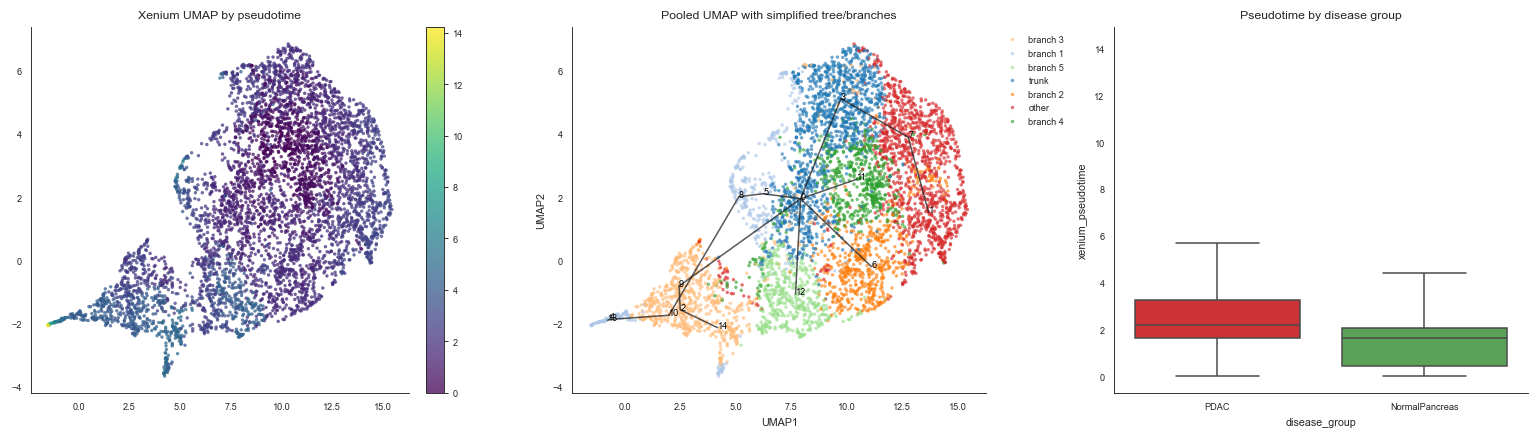

In [8]:

def compute_umap_tree_nodes(pg_tree, X_pca_use, X_umap):
    node_positions = pg_tree["NodePositions"]
    nbrs = NearestNeighbors(n_neighbors=min(60, len(X_pca_use))).fit(X_pca_use)
    node_umap = []
    for node_pos in node_positions:
        _, idx = nbrs.kneighbors(node_pos.reshape(1, -1))
        node_umap.append(np.median(X_umap[idx[0]], axis=0))
    return np.asarray(node_umap)

def plot_tree_overlay(ax, result_df, pg_tree, node_umap, color_col, palette=None, point_size=5):
    sns.scatterplot(
        data=result_df,
        x="UMAP1",
        y="UMAP2",
        hue=color_col,
        palette=palette,
        s=point_size,
        linewidth=0,
        alpha=0.65,
        ax=ax,
    )
    for u, v in tree_edges(pg_tree):
        ax.plot(
            [node_umap[u, 0], node_umap[v, 0]],
            [node_umap[u, 1], node_umap[v, 1]],
            color="#222222",
            linewidth=1.0,
            alpha=0.75,
        )
    for node, xy in enumerate(node_umap):
        ax.text(xy[0], xy[1], str(node), fontsize=6, color="black")
    ax.grid(False)

node_umap = compute_umap_tree_nodes(pg_tree_simple, reduced_data, X_umap)
branch_order = ["trunk"] + sorted([b for b in result_df["major_branch"].unique() if b not in {"trunk", "other"}]) + ["other"]
branch_palette = dict(zip(branch_order, sns.color_palette("tab20", n_colors=len(branch_order))))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
scat = axes[0].scatter(
    result_df["UMAP1"],
    result_df["UMAP2"],
    c=result_df["xenium_pseudotime"],
    s=5,
    linewidth=0,
    cmap="viridis",
    alpha=0.75,
)
axes[0].set_title("Xenium UMAP by pseudotime")
axes[0].grid(False)
plt.colorbar(scat, ax=axes[0], fraction=0.046, pad=0.04)

plot_tree_overlay(
    axes[1],
    result_df,
    pg_tree_simple,
    node_umap,
    color_col="major_branch",
    palette=branch_palette,
    point_size=5,
)
axes[1].set_title("Pooled UMAP with simplified tree/branches")
axes[1].legend(frameon=False, fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(
    data=result_df,
    x="disease_group",
    y="xenium_pseudotime",
    hue="disease_group",
    palette={"NormalPancreas": "#4daf4a", "PDAC": "#e41a1c"},
    legend=False,
    fliersize=0,
    ax=axes[2],
)
axes[2].set_title("Pseudotime by disease group")
axes[2].grid(False)

plt.tight_layout()
plt.show()


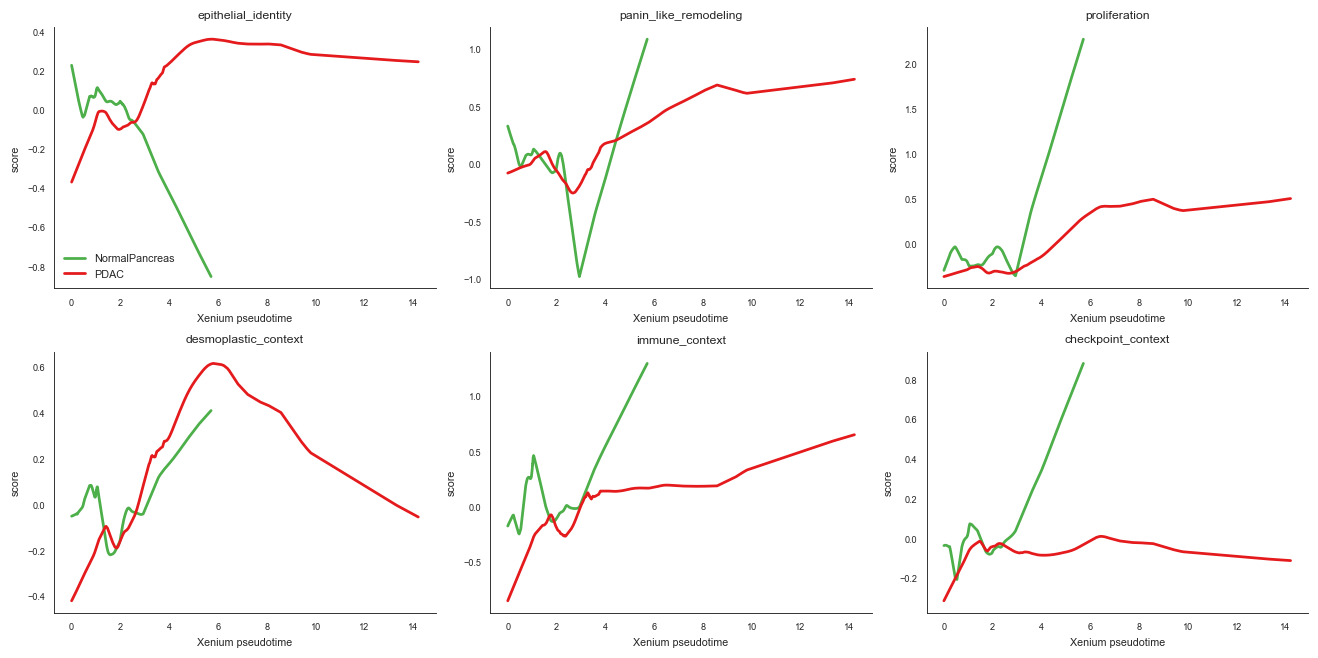

In [9]:

def lowess_or_line(x, y, frac=0.3):
    import statsmodels.api as sm
    tmp = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    if len(tmp) < 20:
        return tmp["x"].to_numpy(), tmp["y"].to_numpy()
    out = sm.nonparametric.lowess(tmp["y"], tmp["x"], frac=frac, return_sorted=True)
    return out[:, 0], out[:, 1]

trend_features = [
    "xenium_epithelial_identity_score",
    "xenium_panin_like_remodeling_score",
    "xenium_proliferation_score",
    "xenium_desmoplastic_context_score",
    "xenium_immune_context_score",
    "xenium_checkpoint_context_score",
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()
for ax, feature in zip(axes, trend_features):
    if feature not in result_df.columns:
        ax.axis("off")
        continue
    for disease, color in {"NormalPancreas": "#4daf4a", "PDAC": "#e41a1c"}.items():
        sub = result_df[result_df["disease_group"] == disease]
        x, y = lowess_or_line(sub["xenium_pseudotime"], sub[feature], frac=0.35)
        ax.plot(x, y, color=color, linewidth=1.8, label=disease)
    ax.set_title(feature.replace("xenium_", "").replace("_score", ""), fontsize=8)
    ax.set_xlabel("Xenium pseudotime")
    ax.set_ylabel("score")
    ax.grid(False)
axes[0].legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()


## Sample Effect Diagnostic and Batch-Aware Sensitivity Trajectory

The pooled Xenium datasets can separate by sample because disease, tissue region, panel content, and technical acquisition are partly confounded. This section does **not** replace the original trajectory. It adds a sensitivity trajectory where selected features are z-scored within each sample before PCA/tree fitting, and the root is anchored by normal-like epithelial niches from all samples.

This is especially useful for checking residual normal pancreas regions inside PDAC samples. If those niches are late only in the original trajectory but early/intermediate after sample-centering, the original result is likely influenced by sample-specific feature shifts.


In [10]:

from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import f_classif

def minmax(values):
    values = np.asarray(values, dtype=float)
    lo = np.nanmin(values)
    hi = np.nanmax(values)
    if not np.isfinite(hi - lo) or np.isclose(hi, lo):
        return np.full(values.shape, np.nan)
    return (values - lo) / (hi - lo)

def knn_purity(embedding, labels, n_neighbors=15):
    labels = np.asarray(labels).astype(str)
    nbrs = NearestNeighbors(n_neighbors=min(n_neighbors + 1, len(embedding))).fit(embedding)
    idx = nbrs.kneighbors(return_distance=False)[:, 1:]
    return (labels[idx] == labels[:, None]).mean(axis=1)

sample_ids = pooled_niche_feature_df["sample_id"].astype(str)
disease_ids = pooled_niche_feature_df["disease_group"].astype(str)
same_sample_fraction = knn_purity(X_pca_use, sample_ids, n_neighbors=15)
same_disease_fraction = knn_purity(X_pca_use, disease_ids, n_neighbors=15)

sample_effect_qc_df = pd.DataFrame(
    {
        "sample_id": sample_ids,
        "disease_group": disease_ids,
        "same_sample_fraction": same_sample_fraction,
        "same_disease_fraction": same_disease_fraction,
        "xenium_pseudotime": result_df["xenium_pseudotime"],
    }
)

feature_sample_F, _ = f_classif(
    StandardScaler().fit_transform(X_pool),
    sample_ids.to_numpy(),
)
sample_discriminating_feature_df = (
    pd.DataFrame({"feature": X_pool.columns, "sample_F": feature_sample_F})
    .sort_values("sample_F", ascending=False)
    .reset_index(drop=True)
)

display(
    sample_effect_qc_df.groupby(["sample_id", "disease_group"])[
        ["same_sample_fraction", "same_disease_fraction", "xenium_pseudotime"]
    ]
    .median()
    .round(3)
)
display(sample_discriminating_feature_df.head(20))


,,same_sample_fraction,same_disease_fraction,xenium_pseudotime
sample_id,disease_group,,,
normal_nondiseased_v1,NormalPancreas,0.867,0.867,1.612
pdac_addon_v1,PDAC,0.800,0.933,1.619
pdac_io_v1,PDAC,1.000,1.000,3.956
pdac_pancreas_v1,PDAC,0.867,1.000,2.101


,feature,sample_F
0,state__TOP2A_expr_z__p10,3.142793e+18
1,state__nucleus_boundary_solidity__p90,4.987139e+03
2,state__AGR3_expr_z__p10,4.927746e+03
3,state__nucleus_boundary_irregularity__median,4.340459e+03
4,state__EPCAM_expr_z__p90,3.452206e+03
5,state__nucleus_boundary_irregularity__p10,3.217643e+03
6,state__nucleus_boundary_solidity__median,3.027460e+03
7,state__dapi_inertia_z__p10,2.752359e+03
8,state__dapi_area_um2__std,2.638166e+03
9,state__nucleus_boundary_solidity__mean,2.619045e+03


In [11]:
# ── DIAGNOSTIC ONLY: sample-centered trajectory ─────────────────────────────
# [caveat] Per-sample centering removes between-sample disease-stage differences
# which ARE the biology of interest. This trajectory flattens the Normal→PDAC
# gradient (all samples converge to similar pseudotime after centering).
# Use this ONLY to diagnose panel batch effects, NOT as the primary trajectory.


def sample_center_feature_matrix(X, sample_ids):
    X_centered = X.copy()
    sample_ids = pd.Series(sample_ids, index=X.index).astype(str)
    for sample_id in sample_ids.unique():
        idx = sample_ids == sample_id
        mu = X_centered.loc[idx].mean(axis=0)
        sd = X_centered.loc[idx].std(axis=0, ddof=0).replace(0, np.nan)
        X_centered.loc[idx] = (X_centered.loc[idx] - mu) / sd
    return X_centered.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def build_normal_like_root_mask(df):
    epi = pd.to_numeric(df["xenium_epithelial_identity_score"], errors="coerce")
    normal_mask = df["disease_group"].astype(str).eq("NormalPancreas")
    root_normal = normal_mask & (epi >= epi[normal_mask].quantile(0.85))

    normal_like = epi >= epi.quantile(0.50)
    for feature, quantile in [
        ("xenium_panin_like_remodeling_score", 0.40),
        ("xenium_proliferation_score", 0.50),
        ("xenium_desmoplastic_context_score", 0.40),
        ("xenium_immune_context_score", 0.40),
    ]:
        if feature in df.columns:
            vals = pd.to_numeric(df[feature], errors="coerce")
            normal_like &= vals <= vals.quantile(quantile)

    root_mask = root_normal | normal_like
    if root_mask.sum() < 20:
        root_mask = root_normal
    if root_mask.sum() == 0:
        root_mask = normal_mask
    return root_mask.fillna(False)

X_pool_sample_centered = sample_center_feature_matrix(X_pool, pooled_niche_feature_df["sample_id"])
X_sample_centered_scaled_df = sv_block_balance_feature_matrix(X_pool_sample_centered, feature_blocks=feature_block_df)
X_sample_centered_scaled = X_sample_centered_scaled_df.to_numpy()
X_pca_sample_centered = PCA(
    n_components=min(12, X_sample_centered_scaled.shape[1]),
    random_state=RANDOM_STATE,
).fit_transform(X_sample_centered_scaled)
X_pca_sample_centered_use = X_pca_sample_centered[:, : min(6, X_pca_sample_centered.shape[1])]

X_umap_sample_centered = UMAP(
    n_neighbors=15,
    min_dist=0.20,
    n_components=2,
    random_state=RANDOM_STATE,
).fit_transform(X_pca_sample_centered_use)

pg_tree_sample_centered = elpigraph.computeElasticPrincipalTree(
    X=X_pca_sample_centered_use,
    NumNodes=num_nodes,
    Lambda=0.01,
    Mu=0.01,
    MaxNumberOfIterations=50,
)[0]

root_mask_sample_centered = build_normal_like_root_mask(pooled_niche_feature_df)
root_anchor_sample_centered = X_pca_sample_centered_use[root_mask_sample_centered.to_numpy()].mean(axis=0)
source_node_sample_centered = int(
    np.argmin(np.sum((pg_tree_sample_centered["NodePositions"] - root_anchor_sample_centered) ** 2, axis=1))
)
elpigraph.utils.getPseudotime(
    X=X_pca_sample_centered_use,
    PG=pg_tree_sample_centered,
    source=source_node_sample_centered,
    target=None,
)

result_df["UMAP1_sample_centered"] = X_umap_sample_centered[:, 0]
result_df["UMAP2_sample_centered"] = X_umap_sample_centered[:, 1]
result_df["xenium_pseudotime_sample_centered"] = pg_tree_sample_centered["pseudotime"]
result_df["xenium_pseudotime_norm"] = minmax(result_df["xenium_pseudotime"])
result_df["xenium_pseudotime_sample_centered_norm"] = minmax(result_df["xenium_pseudotime_sample_centered"])
result_df["xenium_node_id_sample_centered"] = pg_tree_sample_centered["projection"]["node_id"]
result_df["xenium_edge_id_sample_centered"] = pg_tree_sample_centered["projection"]["edge_id"]
result_df["normal_like_root_candidate"] = root_mask_sample_centered.to_numpy()

print("Sample-centered root node:", source_node_sample_centered)
print("Sample-centered root candidates by sample:")
print(pooled_niche_feature_df.loc[root_mask_sample_centered, "sample_id"].value_counts().to_string())

display(
    result_df.groupby(["sample_id", "disease_group"])[
        ["xenium_pseudotime", "xenium_pseudotime_sample_centered"]
    ]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(3)
)


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_17834/3123329365.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.26713661 -0.62375621 -0.49508014 ...  0.14830026 -0.49508014
  0.27697633]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_centered.loc[idx] = (X_centered.loc[idx] - mu) / sd
/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_17834/3123329365.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-2.16503994 -1.89878446 -2.0319122  ...  0.36438709 -0.56750708
  0.36438709]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_centered.loc[idx] = (X_centered.loc[idx] - mu) / sd
/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_17834/3123329365.py:15: FutureWarning: Setting an item of incompatible 

Sample-centered root node: 0
Sample-centered root candidates by sample:
sample_id
normal_nondiseased_v1    282
pdac_pancreas_v1          29
pdac_addon_v1             23
pdac_io_v1                 6


xenium_pseudotime                       \
                                                 count   mean    std    min   
sample_id             disease_group                                           
normal_nondiseased_v1 NormalPancreas            1777.0  1.402  0.907  0.000   
pdac_addon_v1         PDAC                      1215.0  1.853  1.095  0.000   
pdac_io_v1            PDAC                       587.0  3.636  1.417  1.249   
pdac_pancreas_v1      PDAC                      1495.0  2.552  1.174  0.122   

                                                                   \
                                        25%    50%    75%     max   
sample_id             disease_group                                 
normal_nondiseased_v1 NormalPancreas  0.439  1.612  2.071   5.717   
pdac_addon_v1         PDAC            1.140  1.619  2.469   7.220   
pdac_io_v1            PDAC            2.748  3.956  4.127  14.210   
pdac_pancreas_v1      PDAC            1.745  2.101  2.937  14.210   

                                     xenium_pseudotime_sample_centered         \
                                                                 count   mean   
sample_id             disease_group                                             
normal_nondiseased_v1 NormalPancreas                            1777.0  1.645   
pdac_addon_v1         PDAC                                      1215.0  1.753   
pdac_io_v1            PDAC                                       587.0  1.697   
pdac_pancreas_v1      PDAC                                      1495.0  1.682   

                                                                                
                                        std    min    25%    50%    75%    max  
sample_id             disease_group                                             
normal_nondiseased_v1 NormalPancreas  1.051  0.067  0.855  1.495  2.306  9.028  
pdac_addon_v1         PDAC            1.002  0.076  1.088  1.590  2.310  9.028  
pdac_io_v1            PDAC            1.054  0.044  1.011  1.492  2.085  9.028  
pdac_pancreas_v1      PDAC            1.065  0.092  0.897  1.548  2.295  9.028

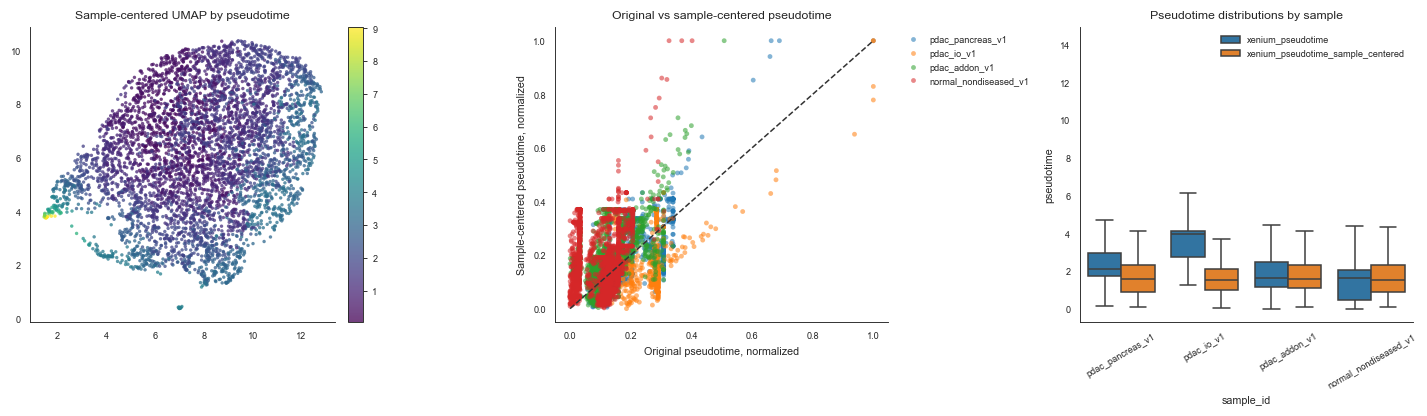

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

s0 = axes[0].scatter(
    result_df["UMAP1_sample_centered"],
    result_df["UMAP2_sample_centered"],
    c=result_df["xenium_pseudotime_sample_centered"],
    s=5,
    linewidth=0,
    alpha=0.75,
    cmap="viridis",
)
axes[0].set_title("Sample-centered UMAP by pseudotime")
axes[0].grid(False)
plt.colorbar(s0, ax=axes[0], fraction=0.046, pad=0.04)

sns.scatterplot(
    data=result_df,
    x="xenium_pseudotime_norm",
    y="xenium_pseudotime_sample_centered_norm",
    hue="sample_id",
    palette="tab10",
    s=10,
    linewidth=0,
    alpha=0.55,
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], color="#333333", linewidth=1, linestyle="--")
axes[1].set_xlabel("Original pseudotime, normalized")
axes[1].set_ylabel("Sample-centered pseudotime, normalized")
axes[1].set_title("Original vs sample-centered pseudotime")
axes[1].grid(False)
axes[1].legend(frameon=False, fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

plot_df = result_df.melt(
    id_vars=["sample_id", "disease_group"],
    value_vars=["xenium_pseudotime", "xenium_pseudotime_sample_centered"],
    var_name="trajectory",
    value_name="pseudotime",
)
sns.boxplot(
    data=plot_df,
    x="sample_id",
    y="pseudotime",
    hue="trajectory",
    fliersize=0,
    ax=axes[2],
)
axes[2].set_title("Pseudotime distributions by sample")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(False)
axes[2].legend(frameon=False, fontsize=6)

plt.tight_layout()
plt.show()


## Clinical Metadata Sanity Check

The clinical labels are **not** used to fit the trajectory. They are added here as an external interpretation layer: if the morphology/transcriptome-driven trajectory is sensible, the clinical contexts should show interpretable enrichment patterns without requiring a perfectly linear stage order.


,sample_id,clinical_progression_label,clinical_diagnosis,clinical_stage,clinical_grade,tumor_content_percent,n_niches,pseudotime_median,pseudotime_q25,pseudotime_q75,sample_centered_pseudotime_median,sample_centered_pseudotime_q25,sample_centered_pseudotime_q75
0,normal_nondiseased_v1,Normal pancreas,Nondiseased pancreas,Normal,Normal,0.0,1777,1.612416,0.438750,2.070793,1.494612,0.855315,2.305991
1,pdac_addon_v1,"Grade I-II, 50% tumor",Adenocarcinoma,Not provided,Grade I-II,50.0,1215,1.618775,1.140098,2.468725,1.590237,1.088259,2.309677
3,pdac_pancreas_v1,Stage III adenocarcinoma,Adenocarcinoma,Stage III,Not provided,NaN,1495,2.101368,1.744543,2.937137,1.548237,0.896624,2.295091
2,pdac_io_v1,"Stage IIB, Grade 3 PDAC",Pancreatic ductal adenocarcinoma,Stage IIB,Grade 3,NaN,587,3.955567,2.747839,4.126963,1.492431,1.011281,2.085457


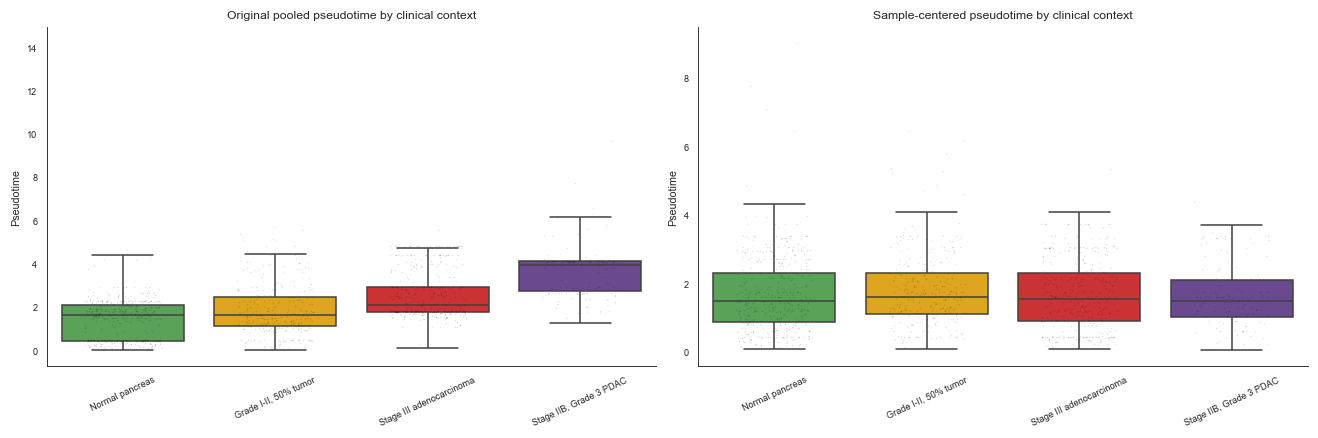

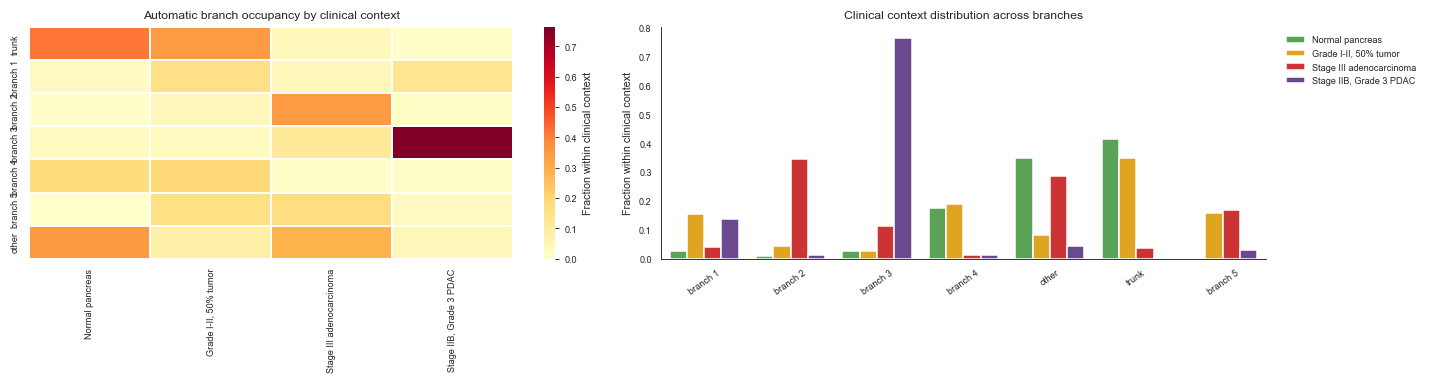

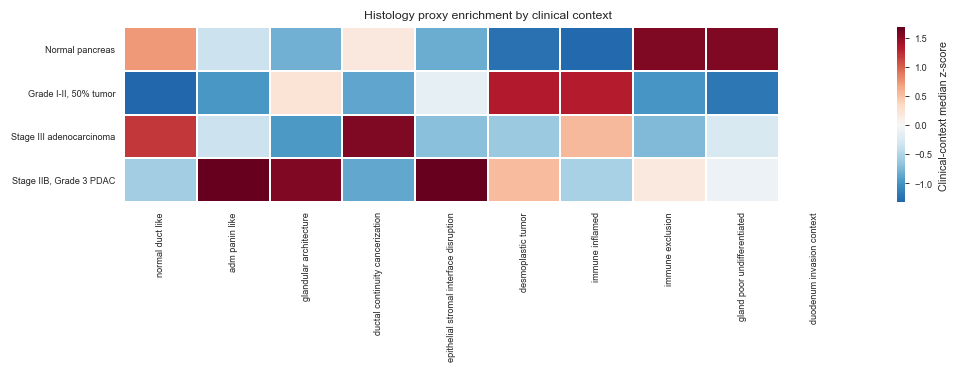

In [13]:

clinical_plot_df = result_df.copy()
clinical_plot_df["clinical_progression_label"] = pd.Categorical(
    clinical_plot_df["clinical_progression_label"],
    categories=CLINICAL_LABEL_ORDER,
    ordered=True,
)

clinical_summary_df = (
    clinical_plot_df.groupby(
        [
            "sample_id",
            "clinical_progression_label",
            "clinical_diagnosis",
            "clinical_stage",
            "clinical_grade",
            "tumor_content_percent",
        ],
        observed=True,
        dropna=False,
    )
    .agg(
        n_niches=(NICHE_KEY, "nunique"),
        pseudotime_median=("xenium_pseudotime", "median"),
        pseudotime_q25=("xenium_pseudotime", lambda x: np.nanquantile(x, 0.25)),
        pseudotime_q75=("xenium_pseudotime", lambda x: np.nanquantile(x, 0.75)),
        sample_centered_pseudotime_median=("xenium_pseudotime_sample_centered", "median"),
        sample_centered_pseudotime_q25=("xenium_pseudotime_sample_centered", lambda x: np.nanquantile(x, 0.25)),
        sample_centered_pseudotime_q75=("xenium_pseudotime_sample_centered", lambda x: np.nanquantile(x, 0.75)),
    )
    .reset_index()
    .sort_values("clinical_progression_label")
)
display(clinical_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_col, title in [
    (axes[0], "xenium_pseudotime", "Original pooled pseudotime by clinical context"),
    (axes[1], "xenium_pseudotime_sample_centered", "Sample-centered pseudotime by clinical context"),
]:
    sns.boxplot(
        data=clinical_plot_df,
        x="clinical_progression_label",
        y=y_col,
        hue="clinical_progression_label",
        order=CLINICAL_LABEL_ORDER,
        palette=CLINICAL_PALETTE,
        legend=False,
        fliersize=0,
        ax=ax,
    )
    sns.stripplot(
        data=clinical_plot_df.sample(min(len(clinical_plot_df), 1200), random_state=RANDOM_STATE),
        x="clinical_progression_label",
        y=y_col,
        order=CLINICAL_LABEL_ORDER,
        color="black",
        size=1.0,
        alpha=0.12,
        jitter=0.25,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel("Pseudotime")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(False)

plt.tight_layout()
plt.show()

clinical_branch_occupancy_df = (
    clinical_plot_df.groupby(["clinical_progression_label", "major_branch"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
clinical_branch_occupancy_df["fraction_within_clinical_context"] = (
    clinical_branch_occupancy_df["n"]
    / clinical_branch_occupancy_df.groupby("clinical_progression_label", observed=True)["n"].transform("sum")
)
branch_occupancy_heatmap_df = (
    clinical_branch_occupancy_df.pivot(
        index="major_branch",
        columns="clinical_progression_label",
        values="fraction_within_clinical_context",
    )
    .reindex(index=branch_order, columns=CLINICAL_LABEL_ORDER)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, max(3.5, 0.4 * len(branch_occupancy_heatmap_df))))
sns.heatmap(
    branch_occupancy_heatmap_df,
    cmap="YlOrRd",
    vmin=0,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Fraction within clinical context"},
    ax=axes[0],
)
axes[0].set_title("Automatic branch occupancy by clinical context")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.barplot(
    data=clinical_branch_occupancy_df,
    x="major_branch",
    y="fraction_within_clinical_context",
    hue="clinical_progression_label",
    hue_order=CLINICAL_LABEL_ORDER,
    palette=CLINICAL_PALETTE,
    ax=axes[1],
)
axes[1].set_title("Clinical context distribution across branches")
axes[1].set_xlabel("")
axes[1].set_ylabel("Fraction within clinical context")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(False)
axes[1].legend(frameon=False, fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

clinical_score_cols = [
    col
    for col in [
        "histology__normal_duct_like_score",
        "histology__adm_panin_like_score",
        "histology__glandular_architecture_score",
        "histology__ductal_continuity_cancerization_score",
        "histology__epithelial_stromal_interface_disruption_score",
        "histology__desmoplastic_tumor_score",
        "histology__immune_inflamed_score",
        "histology__immune_exclusion_score",
        "histology__gland_poor_undifferentiated_score",
        "histology__duodenum_invasion_context_score",
    ]
    if col in clinical_plot_df.columns
]
clinical_score_median_df = (
    clinical_plot_df.groupby("clinical_progression_label", observed=True)[clinical_score_cols]
    .median()
    .reindex(CLINICAL_LABEL_ORDER)
)
clinical_score_heatmap_df = clinical_score_median_df.apply(_zscore_series, axis=0)
clinical_score_heatmap_df.columns = [
    col.replace("histology__", "").replace("_score", "").replace("_", " ")
    for col in clinical_score_heatmap_df.columns
]

plt.figure(figsize=(9.5, 3.4))
sns.heatmap(
    clinical_score_heatmap_df,
    cmap="RdBu_r",
    center=0,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Clinical-context median z-score"},
)
plt.title("Histology proxy enrichment by clinical context")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

save_df(clinical_sample_metadata_df, RESULT_DIR / "xenium_clinical_sample_metadata.csv")
save_df(clinical_summary_df, RESULT_DIR / "xenium_clinical_pseudotime_summary.csv")
save_df(clinical_branch_occupancy_df, RESULT_DIR / "xenium_clinical_branch_occupancy.csv")
save_df(clinical_score_median_df.reset_index(), RESULT_DIR / "xenium_clinical_histology_score_medians.csv")


## Intrinsic Epithelial Sensitivity Trajectory

The microenvironment-aware trajectory is useful for disease-state mapping, but fibrosis and immune exclusion can dominate sample separation. This intrinsic sensitivity trajectory uses only epithelial/histology modules, epithelial state, duct architecture, architecture/topology, and nuclear morphology blocks after within-sample centering.


In [14]:

INTRINSIC_FEATURE_BLOCKS = {
    "histology_modules",
    "epithelial_state",
    "duct_architecture",
    "architecture_topology",
    "nuclear_morphology",
}
intrinsic_feature_cols = feature_block_df.loc[
    feature_block_df["feature_block"].isin(INTRINSIC_FEATURE_BLOCKS),
    "feature",
].tolist()
intrinsic_feature_cols = [col for col in intrinsic_feature_cols if col in X_pool.columns]

if len(intrinsic_feature_cols) < 5:
    print("Too few intrinsic features for intrinsic sensitivity trajectory.")
    source_node_intrinsic = None
else:
    X_intrinsic = X_pool[intrinsic_feature_cols].copy()
    X_intrinsic_sample_centered = sample_center_feature_matrix(
        X_intrinsic,
        pooled_niche_feature_df["sample_id"],
    )
    X_intrinsic_scaled_df = sv_block_balance_feature_matrix(X_intrinsic_sample_centered, feature_blocks=feature_block_df)
    intrinsic_feature_block_df = assign_feature_blocks(intrinsic_feature_cols)  # block summary for display
    X_intrinsic_scaled = X_intrinsic_scaled_df.to_numpy()
    X_intrinsic_pca = PCA(
        n_components=min(12, X_intrinsic_scaled.shape[1]),
        random_state=RANDOM_STATE,
    ).fit_transform(X_intrinsic_scaled)
    X_intrinsic_pca_use = X_intrinsic_pca[:, : min(6, X_intrinsic_pca.shape[1])]

    pg_tree_intrinsic = elpigraph.computeElasticPrincipalTree(
        X=X_intrinsic_pca_use,
        NumNodes=num_nodes,
        Lambda=0.01,
        Mu=0.01,
        MaxNumberOfIterations=50,
    )[0]
    root_anchor_intrinsic = X_intrinsic_pca_use[root_mask_sample_centered.to_numpy()].mean(axis=0)
    source_node_intrinsic = int(
        np.argmin(np.sum((pg_tree_intrinsic["NodePositions"] - root_anchor_intrinsic) ** 2, axis=1))
    )
    elpigraph.utils.getPseudotime(
        X=X_intrinsic_pca_use,
        PG=pg_tree_intrinsic,
        source=source_node_intrinsic,
        target=None,
    )
    result_df["xenium_pseudotime_intrinsic_sample_centered"] = pg_tree_intrinsic["pseudotime"]
    result_df["xenium_pseudotime_intrinsic_sample_centered_norm"] = minmax(
        result_df["xenium_pseudotime_intrinsic_sample_centered"]
    )
    result_df["xenium_node_id_intrinsic_sample_centered"] = pg_tree_intrinsic["projection"]["node_id"]
    result_df["xenium_edge_id_intrinsic_sample_centered"] = pg_tree_intrinsic["projection"]["edge_id"]

    print("Intrinsic feature blocks:")
    display(intrinsic_feature_block_df["feature_block"].value_counts().rename("n_features").reset_index())
    print("Intrinsic root node:", source_node_intrinsic)
    display(
        result_df.groupby(["sample_id", "disease_group"])[
            ["xenium_pseudotime_sample_centered", "xenium_pseudotime_intrinsic_sample_centered"]
        ]
        .median()
        .round(3)
    )


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_17834/3123329365.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-2.16503994 -1.89878446 -2.0319122  ...  0.36438709 -0.56750708
  0.36438709]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_centered.loc[idx] = (X_centered.loc[idx] - mu) / sd


Intrinsic feature blocks:


,feature_block,n_features
0,nuclear_morphology,177
1,epithelial_state,42
2,architecture_topology,26
3,duct_architecture,12
4,histology_modules,9


Intrinsic root node: 13


,,xenium_pseudotime_sample_centered,xenium_pseudotime_intrinsic_sample_centered
sample_id,disease_group,,
normal_nondiseased_v1,NormalPancreas,1.495,1.845
pdac_addon_v1,PDAC,1.590,2.064
pdac_io_v1,PDAC,1.492,1.746
pdac_pancreas_v1,PDAC,1.548,1.888


## Automatic Branch Annotation

Branch IDs are assigned from the simplified tree structure. The table below does not hard-code biology; it summarizes each branch by sample composition, pseudotime, and histology proxy enrichment, then proposes a suggested biological identity for review.


In [15]:

BRANCH_BIOLOGY_SCORE_COLS = [
    col
    for col in [
        "histology__normal_duct_like_score",
        "histology__adm_panin_like_score",
        "histology__glandular_architecture_score",
        "histology__ductal_continuity_cancerization_score",
        "histology__epithelial_stromal_interface_disruption_score",
        "histology__desmoplastic_tumor_score",
        "histology__immune_inflamed_score",
        "histology__immune_exclusion_score",
        "histology__duodenum_invasion_context_score",
        "histology__gland_poor_undifferentiated_score",
        "xenium_epithelial_identity_score",
        "xenium_panin_like_remodeling_score",
        "xenium_proliferation_score",
        "xenium_desmoplastic_context_score",
        "xenium_immune_context_score",
        "xenium_checkpoint_context_score",
        "xenium_nuclear_dapi_texture_score",
        "xenium_duct_lumen_topology_score",
        "xenium_duct_continuity_cancerization_score",
        "xenium_epithelial_stromal_interface_disruption_score",
    ]
    if col in result_df.columns
]

SAMPLE_HISTOLOGY_CONTEXT = {
    "normal_nondiseased_v1": "normal pancreas reference",
    "pdac_addon_v1": "Grade I-II adenocarcinoma, 50% tumor; earlier PDAC with preserved lobular architecture, interlobular fibrosis, glandular tumor/PanIN regions",
    "pdac_pancreas_v1": "Stage III adenocarcinoma; mixed residual normal pancreas, ADM/PanIN, and desmoplastic glandular tumor regions",
    "pdac_io_v1": "Stage IIB Grade 3 PDAC; less fibrotic, gland-poor/undifferentiated-looking, duodenum-invasive, immune-exclusive tumor",
}

def branch_score_enrichment(df, score_cols):
    out = {}
    for col in score_cols:
        vals = pd.to_numeric(df[col], errors="coerce")
        out[col] = vals.median()
    return out

def summarize_auto_branches(df, branch_col="major_branch"):
    rows = []
    score_median_all = {
        col: pd.to_numeric(df[col], errors="coerce").median()
        for col in BRANCH_BIOLOGY_SCORE_COLS
    }
    score_sd_all = {
        col: pd.to_numeric(df[col], errors="coerce").std(ddof=0)
        for col in BRANCH_BIOLOGY_SCORE_COLS
    }

    for branch, sub in df.groupby(branch_col, observed=True):
        sample_fracs = sub["sample_id"].value_counts(normalize=True)
        disease_fracs = sub["disease_group"].value_counts(normalize=True)
        row = {
            "branch": branch,
            "n_niches": len(sub),
            "fraction_of_all_niches": len(sub) / len(df),
            "median_original_pseudotime": pd.to_numeric(sub["xenium_pseudotime"], errors="coerce").median(),
            "median_sample_centered_pseudotime": pd.to_numeric(sub["xenium_pseudotime_sample_centered"], errors="coerce").median(),
            "dominant_sample": sample_fracs.index[0],
            "dominant_sample_fraction": sample_fracs.iloc[0],
            "dominant_sample_histology_context": SAMPLE_HISTOLOGY_CONTEXT.get(sample_fracs.index[0], ""),
            "dominant_disease_group": disease_fracs.index[0],
            "dominant_disease_fraction": disease_fracs.iloc[0],
        }
        for sample_id, frac in sample_fracs.items():
            row[f"sample_frac__{sample_id}"] = frac
        for col in BRANCH_BIOLOGY_SCORE_COLS:
            median_val = pd.to_numeric(sub[col], errors="coerce").median()
            sd = score_sd_all[col]
            row[f"{col}__median"] = median_val
            row[f"{col}__z_enrichment"] = (
                (median_val - score_median_all[col]) / sd
                if np.isfinite(sd) and not np.isclose(sd, 0)
                else np.nan
            )
        rows.append(row)

    branch_summary = pd.DataFrame(rows)
    branch_summary["branch"] = pd.Categorical(branch_summary["branch"], categories=branch_order, ordered=True)
    return branch_summary.sort_values(["branch"]).reset_index(drop=True)

def row_score(row, name):
    return row.get(f"{name}__z_enrichment", np.nan)

def suggest_branch_biology(row):
    sample_io = row.get("sample_frac__pdac_io_v1", 0.0)
    sample_pancreas = row.get("sample_frac__pdac_pancreas_v1", 0.0)
    sample_addon = row.get("sample_frac__pdac_addon_v1", 0.0)
    sample_normal = row.get("sample_frac__normal_nondiseased_v1", 0.0)

    # Histology-informed sample priors are only used when a branch is strongly
    # dominated by a reviewed sample and the proxy scores do not contradict the
    # review. The tree structure and branch assignment remain automatic.
    if sample_io >= 0.65:
        immune_inflamed = row_score(row, "histology__immune_inflamed_score")
        desmoplastic = row_score(row, "histology__desmoplastic_tumor_score")
        duodenum_context = row_score(row, "histology__duodenum_invasion_context_score")
        if (
            (pd.isna(immune_inflamed) or immune_inflamed < 0.35)
            and (pd.isna(desmoplastic) or desmoplastic < 0.45)
        ):
            label = "gland-poor / undifferentiated immune-excluded tumor"
            if pd.notna(duodenum_context) and duodenum_context >= -0.10:
                label += " with duodenum-invasion context"
            return label

    if sample_addon >= 0.55:
        adm_panin = row_score(row, "histology__adm_panin_like_score")
        glandular = row_score(row, "histology__glandular_architecture_score")
        if (
            (pd.notna(adm_panin) and adm_panin > 0.20)
            or (pd.notna(glandular) and glandular > 0.25)
        ):
            return "early disease / PanIN-glandular lobule-preserved branch"

    if sample_pancreas >= 0.55:
        desmoplastic = row_score(row, "histology__desmoplastic_tumor_score")
        glandular = row_score(row, "histology__glandular_architecture_score")
        if pd.notna(desmoplastic) and desmoplastic > 0.35:
            if pd.notna(glandular) and glandular > 0.10:
                return "desmoplastic glandular tumor branch"
            return "desmoplastic tumor / stromal-remodeled"

    candidates = {
        "normal / residual normal duct-like": row_score(row, "histology__normal_duct_like_score") + sample_normal,
        "ADM / PanIN-like remodeling": row_score(row, "histology__adm_panin_like_score") + 0.3 * (sample_addon + sample_pancreas),
        "glandular architecture / differentiated tumor": row_score(row, "histology__glandular_architecture_score") + 0.2 * sample_pancreas,
        "ductal continuity / cancerization-like spread": row_score(row, "histology__ductal_continuity_cancerization_score"),
        "interface-disrupted budding / stromal-contact state": row_score(row, "histology__epithelial_stromal_interface_disruption_score"),
        "desmoplastic tumor / stromal-remodeled": row_score(row, "histology__desmoplastic_tumor_score") + 0.3 * sample_pancreas,
        "immune-inflamed epithelial niche": row_score(row, "histology__immune_inflamed_score"),
        "immune-excluded gland-poor / undifferentiated-like": (
            row_score(row, "histology__gland_poor_undifferentiated_score")
            + row_score(row, "histology__immune_exclusion_score")
            + 0.4 * sample_io
        ),
        "duodenum-invasion-associated context": row_score(row, "histology__duodenum_invasion_context_score") + 0.4 * sample_io,
    }
    candidates = {k: v for k, v in candidates.items() if pd.notna(v)}
    if len(candidates) == 0:
        return "mixed / unclear"
    ranked = sorted(candidates.items(), key=lambda item: item[1], reverse=True)
    if ranked[0][1] < 0.35:
        return "mixed / unclear"
    if len(ranked) > 1 and ranked[1][1] > ranked[0][1] - 0.25:
        return f"{ranked[0][0]} + {ranked[1][0]}"
    return ranked[0][0]

branch_biology_summary_df = summarize_auto_branches(result_df)
branch_biology_summary_df["suggested_biology"] = branch_biology_summary_df.apply(suggest_branch_biology, axis=1)

top_feature_rows = []
for _, row in branch_biology_summary_df.iterrows():
    enrichments = []
    for col in BRANCH_BIOLOGY_SCORE_COLS:
        enrichments.append((col, row.get(f"{col}__z_enrichment", np.nan)))
    enrichments = [(col, val) for col, val in enrichments if pd.notna(val)]
    top = sorted(enrichments, key=lambda item: abs(item[1]), reverse=True)[:5]
    top_feature_rows.append("; ".join(f"{col}:{val:+.2f}" for col, val in top))
branch_biology_summary_df["top_enriched_scores"] = top_feature_rows

display_cols = [
    "branch",
    "suggested_biology",
    "n_niches",
    "dominant_sample",
    "dominant_sample_histology_context",
    "dominant_sample_fraction",
    "median_sample_centered_pseudotime",
    "top_enriched_scores",
]
display(branch_biology_summary_df[display_cols])


,branch,suggested_biology,n_niches,dominant_sample,dominant_sample_histology_context,dominant_sample_fraction,median_sample_centered_pseudotime,top_enriched_scores
0,trunk,normal / residual normal duct-like + ADM / Pan...,1218,normal_nondiseased_v1,normal pancreas reference,0.605090,0.964203,xenium_panin_like_remodeling_score:+0.35; xeni...
1,branch 1,glandular architecture / differentiated tumor,371,pdac_addon_v1,"Grade I-II adenocarcinoma, 50% tumor; earlier ...",0.504043,2.262744,xenium_duct_lumen_topology_score:+1.90; histol...
2,branch 2,ADM / PanIN-like remodeling + normal / residua...,593,pdac_pancreas_v1,Stage III adenocarcinoma; mixed residual norma...,0.873524,0.811768,histology__immune_exclusion_score:-0.58; histo...
3,branch 3,interface-disrupted budding / stromal-contact ...,696,pdac_io_v1,"Stage IIB Grade 3 PDAC; less fibrotic, gland-p...",0.643678,1.757987,histology__normal_duct_like_score:-0.68; xeniu...
4,branch 4,immune-excluded gland-poor / undifferentiated-...,563,normal_nondiseased_v1,normal pancreas reference,0.550622,1.956965,histology__ductal_continuity_cancerization_sco...
5,branch 5,duodenum-invasion-associated context,458,pdac_pancreas_v1,Stage III adenocarcinoma; mixed residual norma...,0.548035,2.110833,histology__duodenum_invasion_context_score:+5....
6,other,immune-excluded gland-poor / undifferentiated-...,1175,normal_nondiseased_v1,normal pancreas reference,0.529362,1.590237,xenium_panin_like_remodeling_score:-0.87; hist...


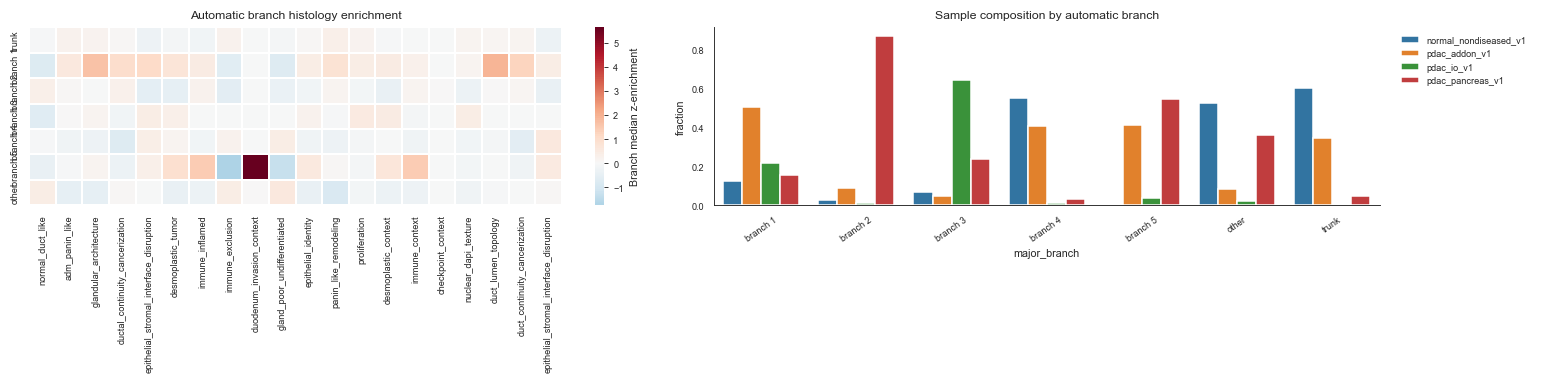

In [16]:

branch_heatmap_cols = [f"{col}__z_enrichment" for col in BRANCH_BIOLOGY_SCORE_COLS]
branch_heatmap_df = branch_biology_summary_df.set_index("branch")[branch_heatmap_cols].copy()
branch_heatmap_df.columns = [
    col.replace("__z_enrichment", "").replace("histology__", "").replace("xenium_", "").replace("_score", "")
    for col in branch_heatmap_df.columns
]

fig, axes = plt.subplots(1, 2, figsize=(14, max(3.5, 0.45 * len(branch_heatmap_df))))
sns.heatmap(
    branch_heatmap_df,
    cmap="RdBu_r",
    center=0,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Branch median z-enrichment"},
    ax=axes[0],
)
axes[0].set_title("Automatic branch histology enrichment")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

branch_sample_comp_df = (
    result_df.groupby(["major_branch", "sample_id"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
branch_sample_comp_df["fraction"] = (
    branch_sample_comp_df["n"]
    / branch_sample_comp_df.groupby("major_branch", observed=True)["n"].transform("sum")
)
sns.barplot(
    data=branch_sample_comp_df,
    x="major_branch",
    y="fraction",
    hue="sample_id",
    palette="tab10",
    ax=axes[1],
)
axes[1].set_title("Sample composition by automatic branch")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(False)
axes[1].legend(frameon=False, fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


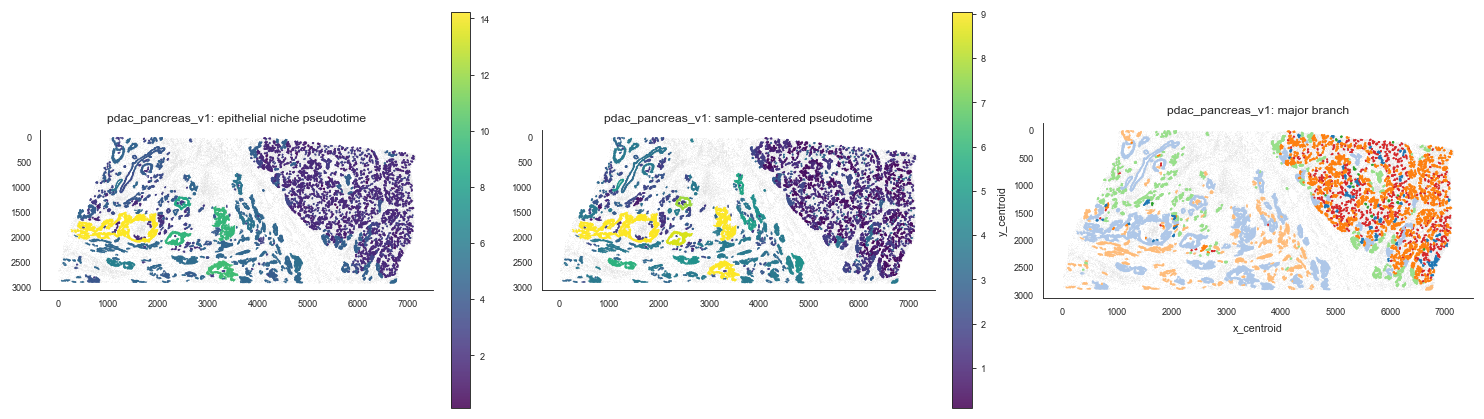

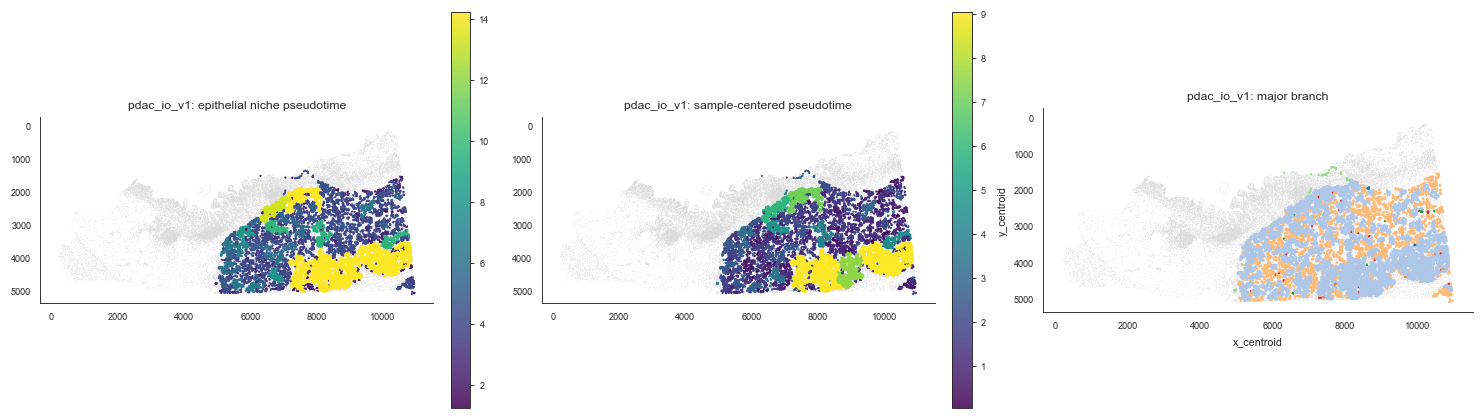

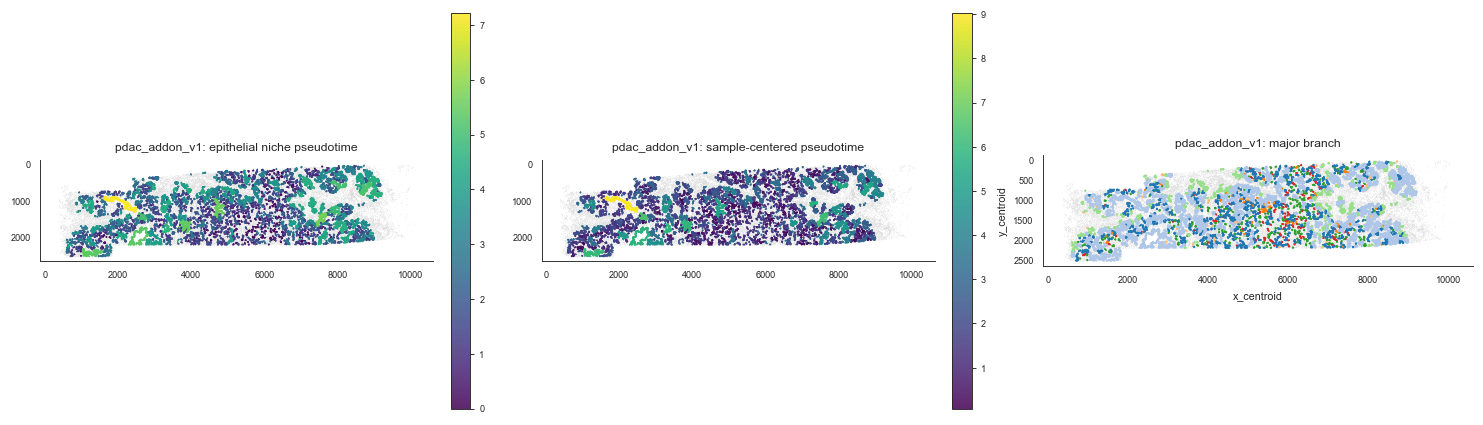

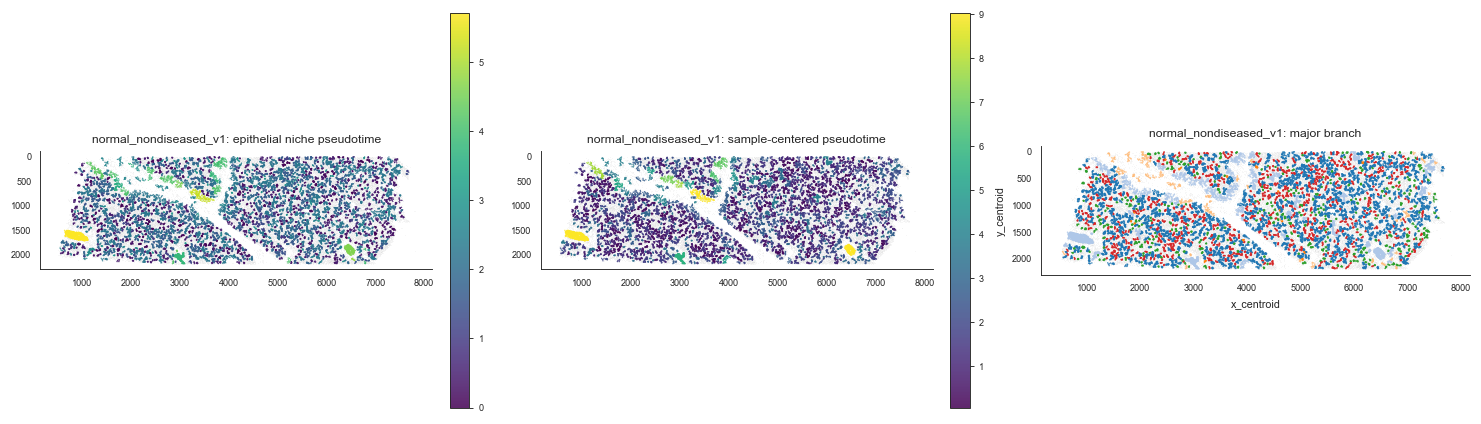

In [17]:

def plot_sample_spatial_pseudotime(sample_id, max_background=80000):
    adata_path = NICHE_DIR / f"{sample_id}_with_niches.h5ad"
    if not adata_path.exists():
        print(f"Missing niche AnnData for {sample_id}: {adata_path}")
        return
    adata = sc.read_h5ad(adata_path, backed="r")
    obs = adata.obs[["x_centroid", "y_centroid", NICHE_KEY, "Tier_A"]].copy()
    adata.file.close()

    lookup_cols = [NICHE_KEY, "xenium_pseudotime", "major_branch"]
    has_sample_centered_pt = "xenium_pseudotime_sample_centered" in result_df.columns
    if has_sample_centered_pt:
        lookup_cols.append("xenium_pseudotime_sample_centered")
    lookup = result_df[result_df["sample_id"] == sample_id][lookup_cols].drop_duplicates()
    obs = obs.merge(lookup, on=NICHE_KEY, how="left")
    rng = np.random.default_rng(42)
    bg = obs
    if len(bg) > max_background:
        bg = bg.iloc[rng.choice(len(bg), size=max_background, replace=False)]
    niche = obs[obs["xenium_pseudotime"].notna()].copy()

    n_panels = 3 if has_sample_centered_pt else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 4))
    axes = np.asarray(axes).reshape(-1)
    axes[0].scatter(bg["x_centroid"], bg["y_centroid"], s=0.2, color="#d9d9d9", alpha=0.25, linewidth=0)
    sc0 = axes[0].scatter(
        niche["x_centroid"],
        niche["y_centroid"],
        c=niche["xenium_pseudotime"],
        s=0.8,
        cmap="viridis",
        linewidth=0,
        alpha=0.85,
    )
    axes[0].set_title(f"{sample_id}: epithelial niche pseudotime")
    axes[0].invert_yaxis()
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].grid(False)
    plt.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)

    panel_idx = 1
    if has_sample_centered_pt:
        axes[panel_idx].scatter(bg["x_centroid"], bg["y_centroid"], s=0.2, color="#d9d9d9", alpha=0.25, linewidth=0)
        sc1 = axes[panel_idx].scatter(
            niche["x_centroid"],
            niche["y_centroid"],
            c=niche["xenium_pseudotime_sample_centered"],
            s=0.8,
            cmap="viridis",
            linewidth=0,
            alpha=0.85,
        )
        axes[panel_idx].set_title(f"{sample_id}: sample-centered pseudotime")
        axes[panel_idx].invert_yaxis()
        axes[panel_idx].set_aspect("equal", adjustable="box")
        axes[panel_idx].grid(False)
        plt.colorbar(sc1, ax=axes[panel_idx], fraction=0.046, pad=0.04)
        panel_idx += 1

    axes[panel_idx].scatter(bg["x_centroid"], bg["y_centroid"], s=0.2, color="#d9d9d9", alpha=0.25, linewidth=0)
    sns.scatterplot(
        data=niche,
        x="x_centroid",
        y="y_centroid",
        hue="major_branch",
        palette=branch_palette,
        s=1.0,
        linewidth=0,
        alpha=0.85,
        ax=axes[panel_idx],
        legend=False,
    )
    axes[panel_idx].set_title(f"{sample_id}: major branch")
    axes[panel_idx].invert_yaxis()
    axes[panel_idx].set_aspect("equal", adjustable="box")
    axes[panel_idx].grid(False)

    plt.tight_layout()
    plt.show()

for cfg in SAMPLE_CONFIGS:
    plot_sample_spatial_pseudotime(cfg["sample_id"])


## Per-sample Pseudotime Concordance

Validate the pooled trajectory by re-fitting ElPiGraph independently per sample and
computing Spearman ρ between pooled and per-sample pseudotime for each sample.
High ρ (>0.5) confirms the pooled axis is not dominated by a single sample.


In [18]:
# ── Per-sample pseudotime concordance: pooled vs single-sample ───────────────
# [reason] With only 4 samples and a known sample-composition effect in branches,
# we must verify the pooled pseudotime is not simply the sample-ID axis.
# For each sample, refit ElPiGraph on just that sample's niches and compute
# Spearman ρ between per-sample pseudotime and pooled pseudotime_q.

from scipy.stats import spearmanr as _spearmanr

CONCORDANCE_NUM_NODES = max(8, min(20, int(np.ceil(np.sqrt(len(result_df)) * 1.5))))

concordance_rows = []
for sample_id in pooled_niche_feature_df["sample_id"].unique():
    mask   = pooled_niche_feature_df["sample_id"] == sample_id
    n      = mask.sum()
    if n < 30:
        print(f"  {sample_id}: too few niches ({n}) for per-sample tree — skip")
        continue

    X_s     = X_scaled[mask.to_numpy()]
    pca_s   = PCA(n_components=min(6, X_s.shape[1]), random_state=RANDOM_STATE)
    X_s_pca = pca_s.fit_transform(X_s)[:, :min(6, X_s.shape[1])]

    n_nodes_s = min(CONCORDANCE_NUM_NODES, max(4, n - 1))
    pg_s = elpigraph.computeElasticPrincipalTree(
        X=X_s_pca, NumNodes=n_nodes_s, Lambda=0.01, Mu=0.01,
        MaxNumberOfIterations=50,
    )[0]

    # Root to the most normal-like niche in this sample
    epi_vals  = pd.to_numeric(pooled_niche_feature_df.loc[mask, "xenium_epithelial_identity_score"], errors="coerce")
    panin_vals= pd.to_numeric(pooled_niche_feature_df.loc[mask, "xenium_panin_like_remodeling_score"], errors="coerce")
    root_score= epi_vals - panin_vals.fillna(0)
    root_thresh = root_score.quantile(0.85)
    root_mask_s = (root_score >= root_thresh).to_numpy()
    if root_mask_s.sum() == 0:
        root_mask_s = np.ones(X_s_pca.shape[0], dtype=bool)
    root_anchor_s = X_s_pca[root_mask_s].mean(axis=0)
    src_s = int(np.argmin(np.sum((pg_s["NodePositions"] - root_anchor_s)**2, axis=1)))

    elpigraph.utils.getPseudotime(X=X_s_pca, PG=pg_s, source=src_s, target=None)
    pt_s = pg_s["pseudotime"]

    # Match back to result_df via index
    pooled_pt = result_df.loc[mask, "xenium_pseudotime_q"].values if "xenium_pseudotime_q" in result_df.columns else result_df.loc[mask, "xenium_pseudotime"].values
    _rho, _p  = _spearmanr(pooled_pt, pt_s)
    concordance_rows.append({
        "sample_id":     sample_id,
        "disease_group": pooled_niche_feature_df.loc[mask, "disease_group"].iloc[0],
        "n_niches":      n,
        "rho":           round(_rho, 3),
        "p_value":       _p,
        "n_nodes_used":  n_nodes_s,
    })
    print(f"  {sample_id}: n={n}, rho={_rho:.3f}, p={_p:.2e}")

concordance_df = pd.DataFrame(concordance_rows)
display(concordance_df)
if concordance_df["rho"].ge(0.50).all():
    print("\n✓ All samples: Spearman ρ ≥ 0.50 — pooled trajectory is not sample-ID driven.")
else:
    low = concordance_df[concordance_df["rho"] < 0.50]["sample_id"].tolist()
    print(f"\n⚠ Low concordance samples: {low} — inspect branch composition for those samples.")


  pdac_pancreas_v1: n=1495, rho=0.114, p=9.44e-06
  pdac_io_v1: n=587, rho=0.773, p=1.65e-117
  pdac_addon_v1: n=1215, rho=-0.118, p=3.97e-05
  normal_nondiseased_v1: n=1777, rho=0.237, p=5.13e-24


,sample_id,disease_group,n_niches,rho,p_value,n_nodes_used
0,pdac_pancreas_v1,PDAC,1495,0.114,9.438450e-06,20
1,pdac_io_v1,PDAC,587,0.773,1.654603e-117,20
2,pdac_addon_v1,PDAC,1215,-0.118,3.969088e-05,20
3,normal_nondiseased_v1,NormalPancreas,1777,0.237,5.134257e-24,20



⚠ Low concordance samples: ['pdac_pancreas_v1', 'pdac_addon_v1', 'normal_nondiseased_v1'] — inspect branch composition for those samples.


In [19]:

save_df(result_df, RESULT_DIR / "xenium_pseudotime_result_df.pkl")
pd.Series(selected_cols, name="feature").to_csv(RESULT_DIR / "xenium_pseudotime_selected_features.csv", index=False)
save_df(feature_block_df, RESULT_DIR / "xenium_pseudotime_feature_blocks.csv")
save_df(histology_proxy_availability_df, RESULT_DIR / "xenium_histology_proxy_availability.csv")
save_df(sample_effect_qc_df, RESULT_DIR / "xenium_sample_effect_qc.csv")
save_df(sample_discriminating_feature_df, RESULT_DIR / "xenium_sample_discriminating_features.csv")
save_df(branch_biology_summary_df, RESULT_DIR / "xenium_branch_biology_summary.csv")
with open(RESULT_DIR / "xenium_branch_definitions.json", "w") as f:
    json.dump(branch_defs, f, indent=2)
with open(RESULT_DIR / "xenium_tree_settings.json", "w") as f:
    json.dump(
        {
            "n_niches": int(n_niches),
            "detailed_num_nodes": int(num_nodes),
            "simplified_num_nodes": int(num_nodes_simple),
            "detailed_root_node": int(source_node),
            "simplified_root_node": int(source_node_simple),
            "sample_centered_root_node": int(source_node_sample_centered),
            "sample_centered_root_niches": int(root_mask_sample_centered.sum()),
            "intrinsic_sample_centered_root_node": (
                int(source_node_intrinsic) if source_node_intrinsic is not None else None
            ),
            "trajectory_scaling": TRAJECTORY_SCALING,
            "detailed_tree_min_nodes": int(DETAILED_TREE_MIN_NODES),
            "detailed_tree_max_nodes": int(DETAILED_TREE_MAX_NODES),
            "detailed_tree_node_scale": float(DETAILED_TREE_NODE_SCALE),
        },
        f,
        indent=2,
    )

result_df.head()


,xenium_ductal_epithelium_component,sample_id,display_name,disease_group,clinical_diagnosis,clinical_stage,clinical_grade,clinical_grade_order,tumor_content_percent,clinical_progression_label,...,xenium_pseudotime_sample_centered,xenium_pseudotime_norm,xenium_pseudotime_sample_centered_norm,xenium_node_id_sample_centered,xenium_edge_id_sample_centered,normal_like_root_candidate,xenium_pseudotime_intrinsic_sample_centered,xenium_pseudotime_intrinsic_sample_centered_norm,xenium_node_id_intrinsic_sample_centered,xenium_edge_id_intrinsic_sample_centered
0,pdac_pancreas_v1__ductal_boundary_00001,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,3.043151,0.177259,0.333858,43,41,False,1.580990,0.180900,4,13
1,pdac_pancreas_v1__ductal_boundary_00002,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,3.718940,0.271870,0.409072,44,42,False,2.886682,0.330300,43,42
2,pdac_pancreas_v1__ductal_boundary_00003,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,3.310453,0.339384,0.363608,28,27,False,2.438432,0.279010,20,19
3,pdac_pancreas_v1__ductal_boundary_00004,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,3.043151,0.339384,0.333858,43,41,False,2.713639,0.310500,20,42
4,pdac_pancreas_v1__ductal_boundary_00005,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Adenocarcinoma,Stage III,Not provided,NaN,NaN,Stage III adenocarcinoma,...,3.043151,0.339384,0.333858,43,41,False,2.060671,0.235786,15,13
